# Instalación

In [ ]:
!pip install sodapy

In [ ]:
!pip install holidays_co

In [2]:
import sys
!{sys.executable} -m pip install pydataxm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 92.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


# Import

In [3]:
import pandas as pd                                            # Librería para manipulación y análisis de datos en estructuras tipo DataFrame, muy útil para limpiar, transformar y explorar datos
import numpy as np                                             # Libreria para procesos matematicos/estadisticos
import matplotlib.pyplot as plt                                # Libreria para gráficos estáticos en 2D como barras, líneas, histogramas, etc.
import seaborn as sns                                          # Librería basada en matplotlib para visualización de datos en 3D
import requests
import pathlib
import datetime as dt                                          # Libreria para manejo de fechas
import os
import time
import math
import unicodedata                                             # Libreria para estandarización de nombres
import re                                                      # Libreria para estandarización de nombres

from pandas import DataFrame
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta                       # Para trabajar con fechas y realizar operaciones de fecha
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_absolute_error, mean_squared_error
from functools import reduce

from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM       # Importa clases para interactuar con datos del sistema SIMEM, utilizado para acceder a información energética en Colombia
from pydataxm.pydataxm import ReadDB                           # API SiMEM
from sodapy import Socrata                                     # API DATOS ABIERTOS GOBIERNO
from holidays_co import *
from io import StringIO                                        # API NASA

import xgboost as xgb
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

ModuleNotFoundError: No module named 'sodapy'

### Funciones auxiliares

In [4]:
#Función para normalizar campos del dataframe
# Se eliminan tíldes, se convierten nombres a minúsculas, se reemplazan espacios por "_" y se eliminan caracteres especiales en caso de existir.
def normalizar_columnas(columnas):
    nuevas = []
    for col in columnas:
        # quitar tildes
        col = unicodedata.normalize('NFKD', col).encode('ascii', 'ignore').decode('utf-8')
        # pasar a minusculas
        col = col.lower()
        # reemplazar espacios por _
        col = col.replace(' ', '_')
        # eliminar caracteres especiales
        col = re.sub(r'[^a-z0-9_]', '', col)
        # eliminar multiples _
        col = re.sub(r'_+', '_', col)
        nuevas.append(col)
    return nuevas

In [5]:
#Función para calcular estadisticas por campo
def reporte_estadistico_por_campo(df, campo):
    reporte = []

    # Variables numéricas reales
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    for campo_value, grupo in df.groupby(campo):

        for col in numeric_cols:

            serie = grupo[col].dropna()

            if serie.empty:
                continue

            media = serie.mean()
            mediana = serie.median()
            moda = serie.mode().iloc[0] if not serie.mode().empty else np.nan
            std = serie.std()

            cv = std / media if media != 0 else np.nan

            Q1 = serie.quantile(0.25)
            Q3 = serie.quantile(0.75)
            IQR = Q3 - Q1

            F1 = Q1 - 1.5 * IQR
            F3 = Q3 + 1.5 * IQR

            B1 = F1 - 1.5 * IQR
            B3 = F3 + 1.5 * IQR

            reporte.append({
                "Variable": col,
                "ZONA": campo_value,
                "Media": media,
                "Mediana": mediana,
                "Moda": moda,
                "Desviación Estándar": std,
                "Coeficiente Variación": cv,
                "Q1": Q1,
                "Q3": Q3,
                "IQR": IQR,
                "F1": F1,
                "F3": F3,
                "B1": B1,
                "B3": B3
            })

    return pd.DataFrame(reporte)

# **Hourly API de NASA POWERs**

In [ ]:
# =========================
# 1. Lista de municipios con coordenadas
# =========================
municipios = {
    "ansermanuevo": (4.796944, -75.993056),
    "buenaventura": (3.877222, -77.026667),
    "buga": (3.9, -76.301944),
    "dagua": (3.6575, -76.691667),
    "palmira": (3.534722, -76.295556),
    "sevilla": (4.269444, -75.931944),
    "zarzal": (4.394167, -76.070278)
}

In [ ]:
zonas = {

    "ansermanuevo": ("norte"),
    "buenaventura": ("occidente"),
    "buga": ("centro_agroind"),
    "dagua": ("centro"),
    "palmira": ("sur"),
    "sevilla": ("oriente"),
    "zarzal": ("norte_agroind")
}

In [ ]:
municipios_completo = {}

for municipio, (lat, lon) in municipios.items():

    if municipio in zonas:
        zona = zonas[municipio]
    else:
        zona = (None)

    municipios_completo[municipio] = {
        "latitud": lat,
        "longitud": lon,
        "zona": zona,
    }

In [ ]:
# =========================
# Parámetros generales
# =========================
START_DATE = "20200101"# Fecha inicial de consulta
END_DATE = "20251231"  # Fecha final de consulta
URL = "https://power.larc.nasa.gov/api/temporal/hourly/point"
PARAMETERS = "ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,RH2M,PRECTOTCORR"

# =========================
# 3. Lista para almacenar los DataFrames de cada municipio
# =========================
df_list = []

# =========================
# 4. Descargar datos por municipio y agregar columna MUNICIPIO
# =========================
for municipio, (lat, lon) in municipios.items():
    print(f"Descargando datos para {municipio}...")

    params = {
        "start": START_DATE,
        "end": END_DATE,
        "latitude": lat,
        "longitude": lon,
        "parameters": PARAMETERS,
        "community": "RE",
        "format": "CSV",
        "units": "metric"
    }

    response = requests.get(URL, params=params)
    response.raise_for_status()

    csv_lines = response.text.splitlines()

    # Eliminar todas las líneas hasta -END HEADER- inclusive
    try:
        end_header_index = csv_lines.index("-END HEADER-")
    except ValueError:
        raise ValueError(f"No se encontró '-END HEADER-' en los datos de {municipio}")

    data_lines = csv_lines[end_header_index + 1:]

    # Leer CSV en DataFrame
    df = pd.read_csv(StringIO("\n".join(data_lines)))

    # Crear columna DATETIME combinando YEAR, MO, DY y HR
    df["DATETIME"] = pd.to_datetime(
        df["YEAR"].astype(str) +
        df["MO"].astype(str).str.zfill(2) +
        df["DY"].astype(str).str.zfill(2),
        format="%Y%m%d"
    ) + pd.to_timedelta(df["HR"], unit="h")

    # Agregar columna MUNICIPIO
    df["MUNICIPIO"] = municipio
    df["ZONA"]= municipios_completo[municipio]["zona"]
    # df["HABITANTES"]= municipios_completo[municipio]["habitantes"]

    # Reemplazar valores faltantes
    df.replace(-999, pd.NA, inplace=True)

    # Agregar a la lista
    df_list.append(df)

# =========================
# 5. Concatenar todos los municipios en un único DataFrame
# =========================
df_consolidado = pd.concat(df_list, ignore_index=True)

Descargando datos para ansermanuevo...
Descargando datos para buenaventura...
Descargando datos para buga...
Descargando datos para dagua...
Descargando datos para palmira...
Descargando datos para sevilla...
Descargando datos para zarzal...


In [ ]:
df_consolidado

,YEAR,MO,DY,HR,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,T2M,RH2M,PRECTOTCORR,DATETIME,MUNICIPIO,ZONA
0,2020,1,1,0,0.0,0.0,19.61,99.95,2.73,2020-01-01 00:00:00,ansermanuevo,norte
1,2020,1,1,1,0.0,0.0,19.53,99.81,2.18,2020-01-01 01:00:00,ansermanuevo,norte
2,2020,1,1,2,0.0,0.0,19.42,99.68,1.99,2020-01-01 02:00:00,ansermanuevo,norte
3,2020,1,1,3,0.0,0.0,19.30,99.38,1.71,2020-01-01 03:00:00,ansermanuevo,norte
4,2020,1,1,4,0.0,0.0,19.17,99.06,1.20,2020-01-01 04:00:00,ansermanuevo,norte
...,...,...,...,...,...,...,...,...,...,...,...,...
368251,2025,12,31,19,<NA>,<NA>,22.22,90.67,4.53,2025-12-31 19:00:00,zarzal,norte_agroind
368252,2025,12,31,20,<NA>,<NA>,21.87,91.79,4.04,2025-12-31 20:00:00,zarzal,norte_agroind
368253,2025,12,31,21,<NA>,<NA>,21.56,92.48,3.17,2025-12-31 21:00:00,zarzal,norte_agroind
368254,2025,12,31,22,<NA>,<NA>,21.17,93.31,2.44,2025-12-31 22:00:00,zarzal,norte_agroind


In [ ]:
# =========================
# Cambiar tipos de columnas
# =========================
df_consolidado["YEAR"] = df_consolidado["YEAR"].astype(object)
df_consolidado["MO"] = df_consolidado["MO"].astype(object)
df_consolidado["DY"] = df_consolidado["DY"].astype(object)
df_consolidado["HR"] = df_consolidado["HR"].astype(object)

df_consolidado["ALLSKY_SFC_SW_DWN"] = pd.to_numeric(df_consolidado["ALLSKY_SFC_SW_DWN"], errors="coerce")
df_consolidado["CLRSKY_SFC_SW_DWN"] = pd.to_numeric(df_consolidado["CLRSKY_SFC_SW_DWN"], errors="coerce")

In [ ]:
df_consolidado.info()

<class 'pandas.DataFrame'>
RangeIndex: 368256 entries, 0 to 368255
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   YEAR               368256 non-null  object        
 1   MO                 368256 non-null  object        
 2   DY                 368256 non-null  object        
 3   HR                 368256 non-null  object        
 4   ALLSKY_SFC_SW_DWN  362880 non-null  float64       
 5   CLRSKY_SFC_SW_DWN  362880 non-null  float64       
 6   T2M                368256 non-null  float64       
 7   RH2M               368256 non-null  float64       
 8   PRECTOTCORR        368256 non-null  float64       
 9   DATETIME           368256 non-null  datetime64[us]
 10  MUNICIPIO          368256 non-null  str           
 11  ZONA               368256 non-null  str           
dtypes: datetime64[us](1), float64(5), object(4), str(2)
memory usage: 39.3+ MB


In [ ]:
df_consolidado["ZONA"].value_counts()

ZONA
norte             52608
occidente         52608
centro_agroind    52608
centro            52608
sur               52608
oriente           52608
norte_agroind     52608
Name: count, dtype: int64

In [ ]:
# Validamos los NaN
print("Column NaN")
print(df_consolidado.isnull().sum())

Column NaN
YEAR                    0
MO                      0
DY                      0
HR                      0
ALLSKY_SFC_SW_DWN    5376
CLRSKY_SFC_SW_DWN    5376
T2M                     0
RH2M                    0
PRECTOTCORR             0
DATETIME                0
MUNICIPIO               0
ZONA                    0
dtype: int64


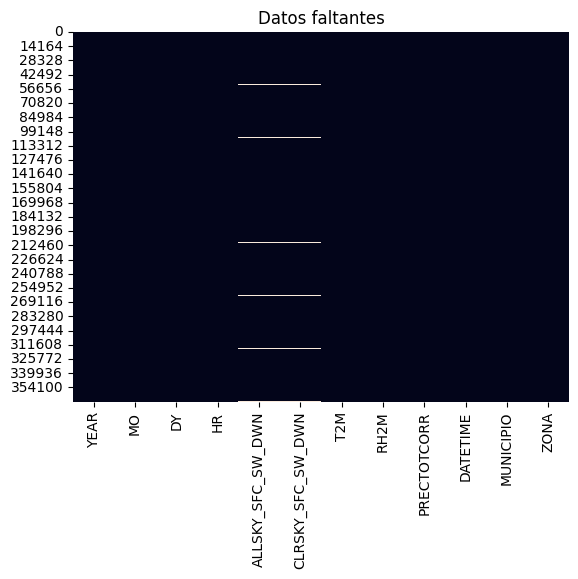

In [ ]:
# Se validan los datos nulos de forma gráfica (si los hubiera)
sns.heatmap(df_consolidado.isnull(), cbar=False)
plt.title("Datos faltantes")
plt.show()

In [ ]:
variables = [
    "ALLSKY_SFC_SW_DWN",
    "CLRSKY_SFC_SW_DWN",
    "T2M",
    "RH2M",
    "PRECTOTCORR"
]

describe_por_zona = (
    df_consolidado
    .groupby("ZONA")[variables]
    .describe()
)

In [ ]:
describe_por_zona.T

ZONA                           centro  centro_agroind         norte  \
ALLSKY_SFC_SW_DWN count  51840.000000    51840.000000  51840.000000   
                  mean     174.510098      174.510098    187.816491   
                  std      233.056366      233.056366    250.535292   
                  min        0.000000        0.000000      0.000000   
                  25%        0.000000        0.000000      0.000000   
                  50%        3.825000        3.825000      2.750000   
                  75%      356.150000      356.150000    387.035000   
                  max      982.720000      982.720000   1022.850000   
CLRSKY_SFC_SW_DWN count  51840.000000    51840.000000  51840.000000   
                  mean     289.395911      289.395911    295.386175   
                  std      368.173184      368.173184    376.029672   
                  min        0.000000        0.000000      0.000000   
                  25%        0.000000        0.000000      0.000000   
                  50%        9.400000        9.400000      9.460000   
                  75%      639.310000      639.310000    632.857500   
                  max     1082.200000     1082.200000   1085.530000   
T2M               count  52608.000000    52608.000000  52608.000000   
                  mean      22.780473       18.647810     21.841520   
                  std        2.330817        3.003666      2.456076   
                  min       17.240000       11.500000     15.710000   
                  25%       21.010000       16.280000     20.010000   
                  50%       22.120000       17.805000     21.280000   
                  75%       24.360000       20.970000     23.290000   
                  max       31.640000       28.050000     30.820000   
RH2M              count  52608.000000    52608.000000  52608.000000   
                  mean      87.372447       85.794948     89.143919   
                  std       11.780509       14.275984     11.578356   
                  min       38.120000       40.910000     48.900000   
                  25%       78.670000       74.260000     82.570000   
                  50%       93.670000       92.900000     94.980000   
                  75%       96.560000       97.580000     97.680000   
                  max      100.000000      100.000000    100.000000   
PRECTOTCORR       count  52608.000000    52608.000000  52608.000000   
                  mean       6.453264        4.348736      8.089125   
                  std       11.470921        8.105016     13.279602   
                  min        0.000000        0.000000      0.000000   
                  25%        0.870000        0.200000      0.620000   
                  50%        2.470000        1.370000      3.140000   
                  75%        6.940000        4.810000      9.770000   
                  max      227.170000      151.450000    229.310000   

ZONA                     norte_agroind     occidente       oriente  \
ALLSKY_SFC_SW_DWN count   51840.000000  51840.000000  51840.000000   
                  mean      172.063639    174.777066    187.816491   
                  std       233.289366    249.915748    250.535292   
                  min         0.000000      0.000000      0.000000   
                  25%         0.000000      0.000000      0.000000   
                  50%         3.450000      4.165000      2.750000   
                  75%       342.057500    318.605000    387.035000   
                  max       965.450000   1008.470000   1022.850000   
CLRSKY_SFC_SW_DWN count   51840.000000  51840.000000  51840.000000   
                  mean      286.758162    277.244744    295.386175   
                  std       364.222956    353.403070    376.029672   
                  min         0.000000      0.000000      0.000000   
                  25%         0.000000      0.000000      0.000000   
                  50%         9.000000      8.190000      9.460000   
                  75%       630.292500

In [ ]:
reporte_df = reporte_estadistico_por_campo(df_consolidado, campo="ZONA")
reporte_df

,Variable,ZONA,Media,Mediana,Moda,Desviación Estándar,Coeficiente Variación,Q1,Q3,IQR,F1,F3,B1,B3
0,ALLSKY_SFC_SW_DWN,centro,174.510098,3.825,0.00,233.056366,1.335489,0.0000,356.1500,356.1500,-534.22500,890.37500,-1068.4500,1424.6000
1,CLRSKY_SFC_SW_DWN,centro,289.395911,9.400,0.00,368.173184,1.272213,0.0000,639.3100,639.3100,-958.96500,1598.27500,-1917.9300,2557.2400
2,T2M,centro,22.780473,22.120,21.34,2.330817,0.102316,21.0100,24.3600,3.3500,15.98500,29.38500,10.9600,34.4100
3,RH2M,centro,87.372447,93.670,100.00,11.780509,0.134831,78.6700,96.5600,17.8900,51.83500,123.39500,25.0000,150.2300
4,PRECTOTCORR,centro,6.453264,2.470,0.27,11.470921,1.777538,0.8700,6.9400,6.0700,-8.23500,16.04500,-17.3400,25.1500
5,ALLSKY_SFC_SW_DWN,centro_agroind,174.510098,3.825,0.00,233.056366,1.335489,0.0000,356.1500,356.1500,-534.22500,890.37500,-1068.4500,1424.6000
6,CLRSKY_SFC_SW_DWN,centro_agroind,289.395911,9.400,0.00,368.173184,1.272213,0.0000,639.3100,639.3100,-958.96500,1598.27500,-1917.9300,2557.2400
7,T2M,centro_agroind,18.647810,17.805,16.24,3.003666,0.161073,16.2800,20.9700,4.6900,9.24500,28.00500,2.2100,35.0400
8,RH2M,centro_agroind,85.794948,92.900,100.00,14.275984,0.166397,74.2600,97.5800,23.3200,39.28000,132.56000,4.3000,167.5400
9,PRECTOTCORR,centro_agroind,4.348736,1.370,0.00,8.105016,1.863763,0.2000,4.8100,4.6100,-6.71500,11.72500,-13.6300,18.6400


In [ ]:
df_modificado=df_consolidado.copy()
df_modificado = df_modificado.rename(columns={
    "ALLSKY_SFC_SW_DWN": "allsky",
    "PRECTOTCORR": "prectotcorr",
    "RH2M": "rh2m",
    "T2M": "t2m",
    "CLRSKY_SFC_SW_DWN": "clrsky"
})

In [ ]:
variables = ["allsky", "clrsky", "t2m", "rh2m", "prectotcorr"]

In [ ]:
df_base = df_modificado[
    ["DATETIME", "ZONA"] + variables
].copy()

In [ ]:
df_long = df_base.melt(
    id_vars=["DATETIME", "ZONA"],
    value_vars=variables,
    var_name="variable",
    value_name="valor"
)

In [ ]:
df_long

,DATETIME,ZONA,variable,valor
0,2020-01-01 00:00:00,norte,allsky,0.00
1,2020-01-01 01:00:00,norte,allsky,0.00
2,2020-01-01 02:00:00,norte,allsky,0.00
3,2020-01-01 03:00:00,norte,allsky,0.00
4,2020-01-01 04:00:00,norte,allsky,0.00
...,...,...,...,...
1841275,2025-12-31 19:00:00,norte_agroind,prectotcorr,4.53
1841276,2025-12-31 20:00:00,norte_agroind,prectotcorr,4.04
1841277,2025-12-31 21:00:00,norte_agroind,prectotcorr,3.17
1841278,2025-12-31 22:00:00,norte_agroind,prectotcorr,2.44


In [ ]:
df_long["columna"] = df_long["variable"] + "_" + df_long["ZONA"]

In [ ]:
df_wide = (
    df_long
    .pivot(index="DATETIME", columns="columna", values="valor")
    .reset_index()
)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# from pathlib import Path
# root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data')

Mounted at /content/drive


In [ ]:
# # Exportación dataset
# root.mkdir(parents=True, exist_ok=True)

# ruta_salida = root / 'df_variables_climaticas_nasa.xlsx'
# df_wide.to_excel(ruta_salida, index=False)

In [ ]:
# # Importación dataset
# df_wide = pd.read_excel(root / 'df_variables_climaticas_nasa.xlsx')

In [ ]:
df_wide["fecha"] = df_wide["DATETIME"].dt.date
df_wide["periodo"] = df_wide["DATETIME"].dt.hour + 1

Validación de registros duplicados

In [ ]:
duplicados = df_wide.duplicated(subset=['DATETIME'], keep=False)
if duplicados.any():
    print("Existen duplicados por DATETIME.")
    print(df_wide[duplicados])
else:
    print("No existen duplicados por DATETIME.")

No existen duplicados por DATETIME.


Validación de completitud de la información

In [ ]:
df_wide = df_wide.set_index("DATETIME").sort_index()
#Construir el rango horario esperado
fecha_min = df_wide.index.min()
fecha_max = df_wide.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"
)

# Horas faltantes
faltantes = rango_horas.difference(df_wide.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(df_wide)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio y estadístico

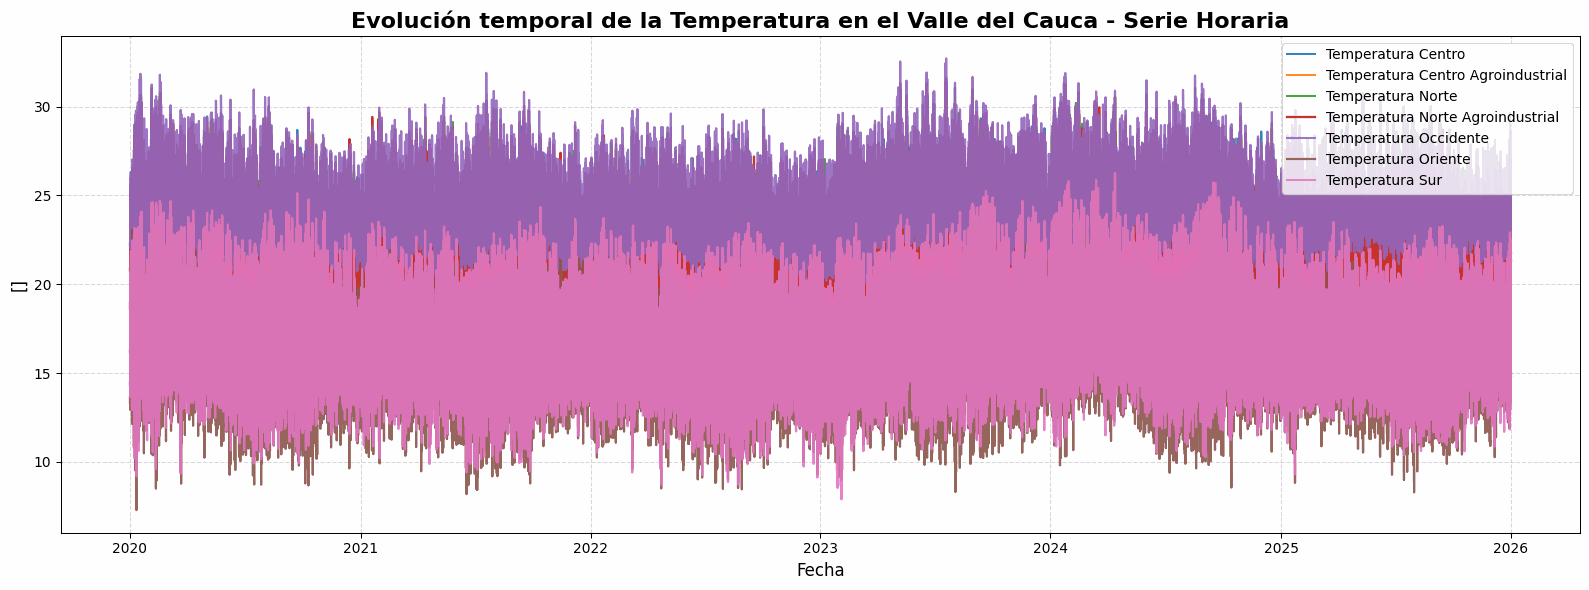

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_wide['t2m_centro'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Centro')
plt.plot(df_wide['t2m_centro_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Centro Agroindustrial')
plt.plot(df_wide['t2m_norte'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Norte')
plt.plot(df_wide['t2m_norte_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Norte Agroindustrial')
plt.plot(df_wide['t2m_occidente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Occidente')
plt.plot(df_wide['t2m_oriente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Oriente')
plt.plot(df_wide['t2m_sur'], linewidth=1.6, linestyle='-', alpha=0.9, label='Temperatura Sur')
plt.title('Evolución temporal de la Temperatura en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

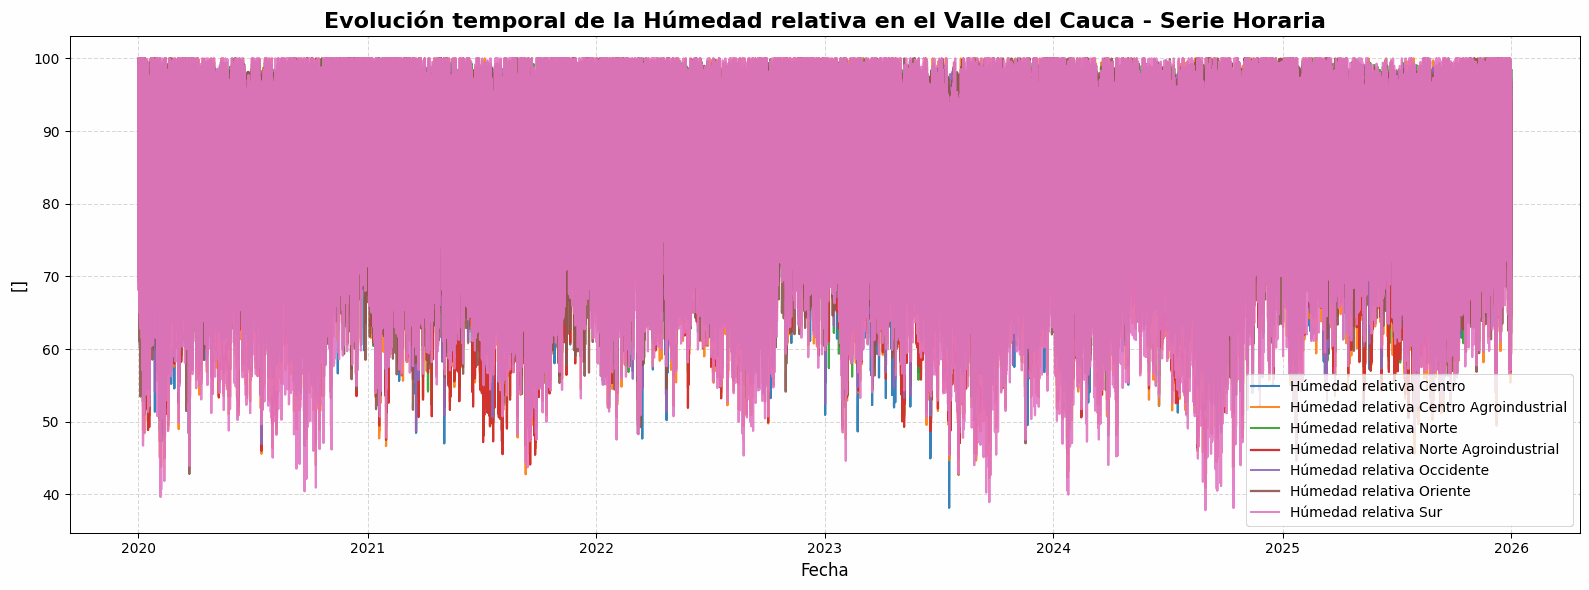

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_wide['rh2m_centro'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Centro')
plt.plot(df_wide['rh2m_centro_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Centro Agroindustrial')
plt.plot(df_wide['rh2m_norte'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Norte')
plt.plot(df_wide['rh2m_norte_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Norte Agroindustrial')
plt.plot(df_wide['rh2m_occidente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Occidente')
plt.plot(df_wide['rh2m_oriente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Oriente')
plt.plot(df_wide['rh2m_sur'], linewidth=1.6, linestyle='-', alpha=0.9, label='Húmedad relativa Sur')
plt.title('Evolución temporal de la Húmedad relativa en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

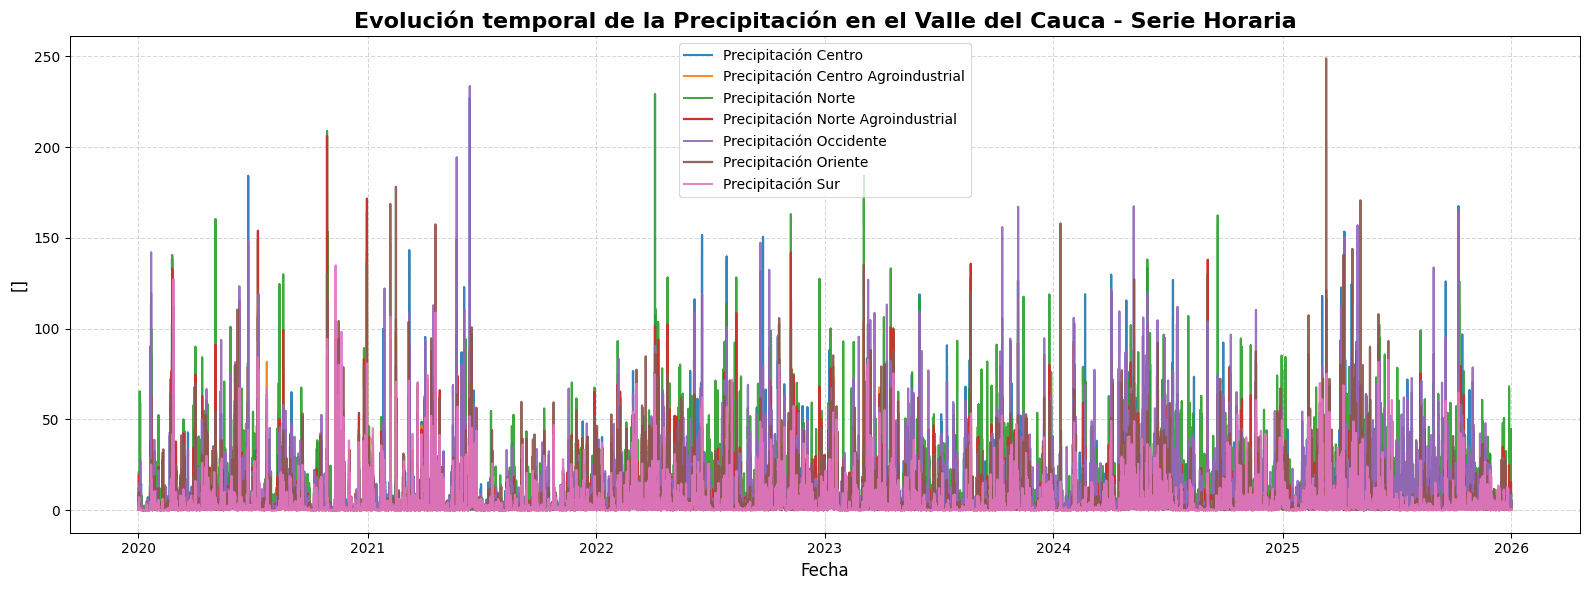

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_wide['prectotcorr_centro'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Centro')
plt.plot(df_wide['prectotcorr_centro_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Centro Agroindustrial')
plt.plot(df_wide['prectotcorr_norte'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Norte')
plt.plot(df_wide['prectotcorr_norte_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Norte Agroindustrial')
plt.plot(df_wide['prectotcorr_occidente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Occidente')
plt.plot(df_wide['prectotcorr_oriente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Oriente')
plt.plot(df_wide['prectotcorr_sur'], linewidth=1.6, linestyle='-', alpha=0.9, label='Precipitación Sur')
plt.title('Evolución temporal de la Precipitación en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

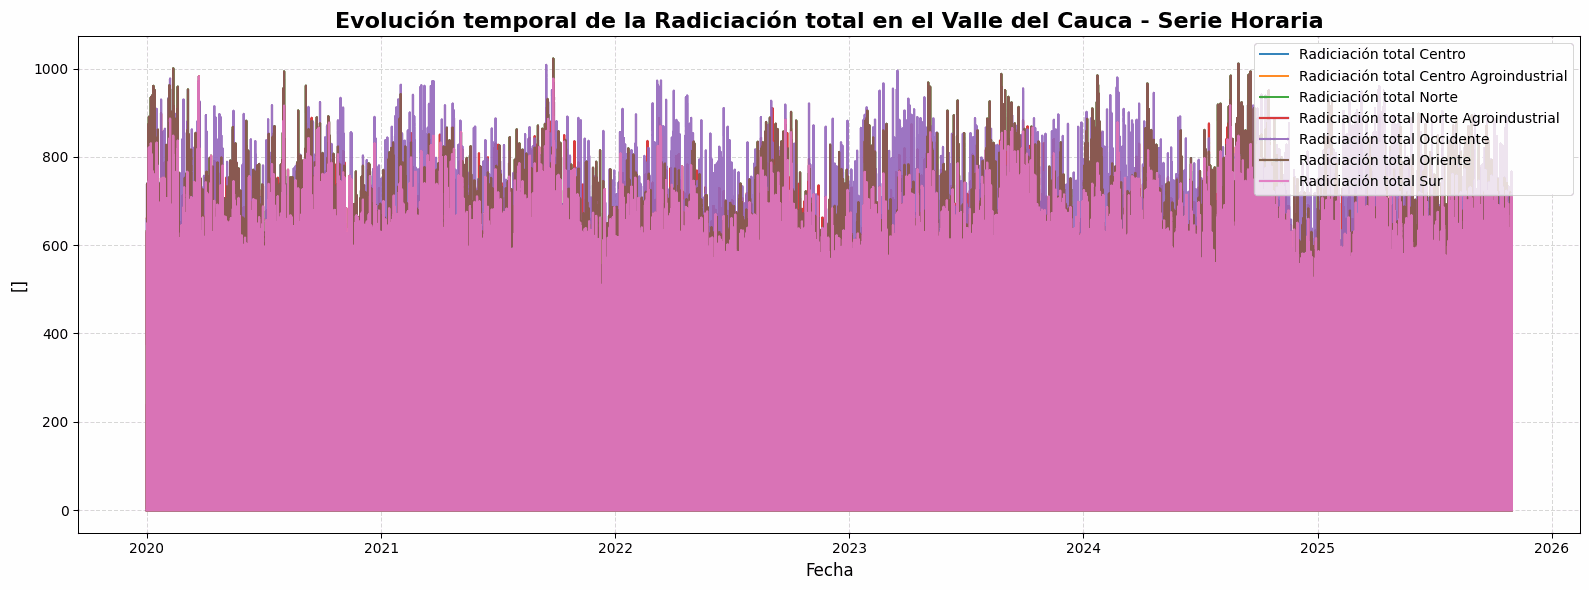

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_wide['allsky_centro'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Centro')
plt.plot(df_wide['allsky_centro_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Centro Agroindustrial')
plt.plot(df_wide['allsky_norte'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Norte')
plt.plot(df_wide['allsky_norte_agroind'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Norte Agroindustrial')
plt.plot(df_wide['allsky_occidente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Occidente')
plt.plot(df_wide['allsky_oriente'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Oriente')
plt.plot(df_wide['allsky_sur'], linewidth=1.6, linestyle='-', alpha=0.9, label='Radiciación total Sur')
plt.title('Evolución temporal de la Radiciación total en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

### 5. Creación del segmento de para análisis del Dataset

In [ ]:
df_climaticas= df_wide.reset_index(drop=True)
df_climaticas['fecha'] = pd.to_datetime(df_climaticas['fecha'])
df_climaticas

,allsky_centro,allsky_centro_agroind,allsky_norte,allsky_norte_agroind,allsky_occidente,allsky_oriente,allsky_sur,clrsky_centro,clrsky_centro_agroind,clrsky_norte,clrsky_norte_agroind,clrsky_occidente,clrsky_oriente,clrsky_sur,prectotcorr_centro,prectotcorr_centro_agroind,prectotcorr_norte,prectotcorr_norte_agroind,prectotcorr_occidente,prectotcorr_oriente,prectotcorr_sur,rh2m_centro,rh2m_centro_agroind,rh2m_norte,rh2m_norte_agroind,rh2m_occidente,rh2m_oriente,rh2m_sur,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur,fecha,periodo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,1.39,2.73,2.12,2.26,1.41,2.21,98.88,100.00,99.95,99.36,98.28,99.54,100.00,20.86,16.33,19.61,18.96,22.32,13.63,14.48,2020-01-01,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.04,1.53,2.18,1.97,2.98,1.61,2.24,98.98,100.00,99.81,99.34,98.46,99.37,100.00,20.79,16.14,19.53,18.89,22.24,13.46,14.28,2020-01-01,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.05,1.73,1.99,2.11,3.98,1.96,2.06,99.16,100.00,99.68,99.25,98.60,99.34,100.00,20.69,15.95,19.42,18.77,22.12,13.27,14.10,2020-01-01,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.30,1.66,1.71,1.99,4.83,1.98,1.64,99.28,100.00,99.38,99.05,98.71,99.26,100.00,20.61,15.78,19.30,18.63,22.04,13.13,13.91,2020-01-01,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.77,1.16,1.20,1.40,5.95,1.40,1.05,99.24,100.00,99.06,98.69,98.68,99.01,100.00,20.57,15.63,19.17,18.49,22.02,13.02,13.77,2020-01-01,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.64,1.80,6.08,4.53,3.07,0.43,0.41,96.19,93.32,98.35,90.67,95.95,94.19,96.91,22.30,18.70,21.89,22.22,23.79,15.52,15.78,2025-12-31,20
52604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.45,1.47,5.91,4.04,2.73,0.38,0.32,96.13,94.33,98.53,91.79,96.46,95.58,97.32,22.25,18.35,21.70,21.87,23.66,15.14,15.52,2025-12-31,21
52605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.29,1.09,5.09,3.17,2.33,0.30,0.23,95.96,95.37,97.94,92.48,96.56,96.17,97.58,22.17,17.98,21.62,21.56,23.55,14.86,15.30,2025-12-31,22
52606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.57,0.83,4.08,2.44,2.37,0.24,0.18,95.95,96.41,97.25,93.31,96.75,96.39,97.61,22.02,17.59,21.52,21.17,23.39,14.68,15.13,2025-12-31,23


# **API SiMEM - XM**

## **PRECIO DE BOLSA**

### Función Auxiliar

In [ ]:
def get_periods(start_date, end_date, months_per_period):
    if isinstance(start_date, str):
        start_date = dt.datetime.strptime(start_date, '%Y-%m-%d').date()

    if isinstance(end_date, str):
        end_date = dt.datetime.strptime(end_date, '%Y-%m-%d').date()

    periods = []
    current_date = start_date

    while current_date <= end_date:
        # Calcular la fecha de finalización del periodo
        period_end = current_date + relativedelta(months=months_per_period) - dt.timedelta(days=1)

        # Asegurarse de que el periodo no sobrepase la fecha final
        if period_end > end_date:
            period_end = end_date

        periods.append((current_date, period_end))

        # Mover la fecha al principio del siguiente periodo
        current_date = period_end + dt.timedelta(days=1)

    return periods

### 1. Consultar información del conjuntos de datos

In [ ]:
def consultar_info(
    id_dataset,
    fecha_inicial,
    fecha_final,
    meses_por_periodo,
    codigo_variable="PB_Nal",
    # version="TX2"
):

    periodos = get_periods(
        start_date=fecha_inicial,
        end_date=fecha_final,
        months_per_period=meses_por_periodo
    )

    dfs = []

    for inicio, fin in periodos:
        print(f"Consultando: {inicio} → {fin}")

        simem = ReadSIMEM(
            dataset_id=id_dataset,
            start_date=inicio.strftime("%Y-%m-%d"),
            end_date=fin.strftime("%Y-%m-%d")
        )

        df_tmp = simem.main()

        # 🔹 Filtros solicitados
        df_tmp = df_tmp[
            (df_tmp["CodigoVariable"] == codigo_variable)
            # &
            # (df_tmp["Version"] == version)
        ]

        dfs.append(df_tmp)

        time.sleep(1)

    if not dfs:
        return pd.DataFrame()

    return (
        pd.concat(dfs, ignore_index=True)
          .drop_duplicates()
          .reset_index(drop=True)
    )

### 2. Extracción de datos

In [ ]:
    df_pb_nal = consultar_info(
    id_dataset="EC6945",
    fecha_inicial="2020-01-01",
    fecha_final="2025-12-31",
    meses_por_periodo=6
)

NameError: name 'consultar_info' is not defined

In [ ]:
df = df_pb_nal.copy()

NameError: name 'df_pb_nal' is not defined

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# from pathlib import Path
# root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# # Exportación dataset
# root.mkdir(parents=True, exist_ok=True)

# ruta_salida = root / 'df_pbolsa_2020-2025.xlsx'
# pb_nal.to_excel(ruta_salida, index=False)

In [ ]:
# # Importación dataset
# df = pd.read_excel(root / 'df_pbolsa_2020-2025.xlsx')

### 3. Manipulación de datos
Los siguientes pasos corresponden a las actividades de manipulación y preparación de los datos que son relevantes para el análisis.

In [ ]:
def filtrar_ultima_version(df, columna_fecha, columna_version, columna_variable=None):                        # Función para filtrar la última versión de registros por mes y variables (opcional)
    fecha_mes_col = 'año_mes'
    orden_version_col = 'orden_version'
    versiones = ['TX1', 'TX2', 'TXR', 'TXF', 'TX3', 'TX4', 'TX5', 'TX6', 'TX7', 'TX8', 'TX9', 'TX10']         # Lista de versiones ordenadas por prioridad
    version_orden = pd.Series(range(1, len(versiones) + 1), index=versiones)                                  # Serie que asigna un orden numérico a cada versión
    df[columna_fecha] = pd.to_datetime(df[columna_fecha])                                                     # Conversión de la columna de fecha a tipo datetime
    df[fecha_mes_col] = df[columna_fecha].dt.to_period('M')                                                   # Se crea una columna con el año y mes del registro
    df[orden_version_col] = df[columna_version].map(version_orden)                                            # Se asigna el orden de versión a cada fila

    if columna_variable is None:                                                                              # Si no se especifican variables adicionales
        df_filtrado = df.sort_values([fecha_mes_col, orden_version_col], ascending=[True, False])             # Ordena por mes y versión descendente
        df_filtrado = df_filtrado.drop_duplicates(subset=[columna_fecha], keep='first')                       # Elimina duplicados conservando la última versión por fecha
    else:                                                                                                     # Si se especifican variables adicionales
        if isinstance(columna_variable, str):                                                                 # Convierte a lista si es un solo string
            columna_variable = [columna_variable]
        orden_columnas = columna_variable + [fecha_mes_col, orden_version_col]                                # Define el orden de columnas para ordenar
        df_filtrado = df.sort_values(orden_columnas, ascending=[True]*len(columna_variable) + [True, False])  # Ordena por variables, mes y versión
        df_filtrado = df_filtrado.drop_duplicates(subset=columna_variable + [columna_fecha], keep='first')    # Elimina duplicados por variables y fecha

    df_filtrado = df_filtrado.drop(columns=[fecha_mes_col, orden_version_col])                                # Elimina columnas auxiliares
    return df_filtrado

Validación de registros duplicados

In [ ]:
pb_nal_filtrado = filtrar_ultima_version(df=df, columna_fecha='FechaHora', columna_version='Version', columna_variable=['CodigoVariable'])

# Validar si luego del filtrado existe algún valor duplicado
duplicados = pb_nal_filtrado.duplicated(subset=['FechaHora', 'Valor'], keep=False)
if duplicados.any():
    print("Existen duplicados por FechaHora y Valor.")
    print(pb_nal_filtrado[duplicados])
else:
    print("No existen duplicados por FechaHora y Valor.")

No existen duplicados por FechaHora y Valor.


Validación de completitud de la información

In [ ]:
pb_nal_filtrado["FechaHora"] = pd.to_datetime(pb_nal_filtrado["FechaHora"])

pb_nal_filtrado = (
    pb_nal_filtrado
        .set_index("FechaHora")
        .sort_index()
)

# Rango horario completo esperado
fecha_min = pb_nal_filtrado.index.min()
fecha_max = pb_nal_filtrado.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"   # pandas >= 2.x
)

# Horas faltantes
faltantes = rango_horas.difference(pb_nal_filtrado.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(pb_nal_filtrado)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio y estadístico

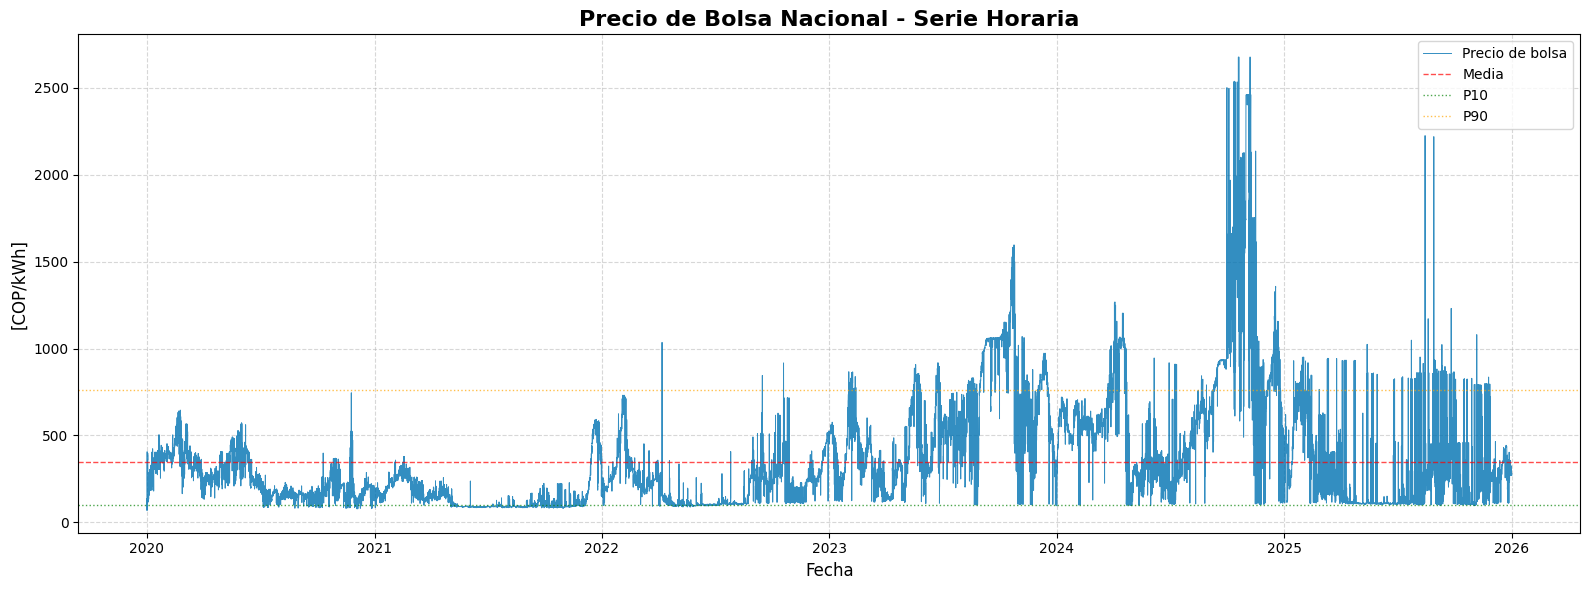

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(pb_nal_filtrado['Valor'], color='#0072B2', linewidth=0.7, alpha=0.8, label='Precio de bolsa')
plt.title('Precio de Bolsa Nacional - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[COP/kWh]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

# Resumen visual: media y percentiles
media = pb_nal_filtrado['Valor'].mean()
p10 = pb_nal_filtrado['Valor'].quantile(0.10)
p90 = pb_nal_filtrado['Valor'].quantile(0.90)
plt.axhline(media, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Media')
plt.axhline(p10, color='green', linestyle=':', linewidth=1, alpha=0.7, label='P10')
plt.axhline(p90, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='P90')
plt.legend()
plt.show()

### 5. Creación del segmento para análisis del Dataset

In [ ]:
df = pb_nal_filtrado.copy()

# Asegurar que el índice sea datetime
df.index = pd.to_datetime(df.index)

# Crear campo fecha (AÑO-MES-DIA)
df['fecha'] = df.index.date

# Crear campo periodo (1 a 24)
df['periodo'] = df.index.hour + 1
df = df.rename(columns={'Valor': 'precio_bolsa'})
df_pbolsa = df[['fecha', 'periodo', 'precio_bolsa']]

In [ ]:
df_pbolsa = df_pbolsa.reset_index(drop=True)
df_pbolsa['fecha'] = pd.to_datetime(df_pbolsa['fecha'])
df_pbolsa

,fecha,periodo,precio_bolsa
0,2020-01-01,1,72.0169
1,2020-01-01,2,136.7139
2,2020-01-01,3,127.7139
3,2020-01-01,4,127.7139
4,2020-01-01,5,127.7139
...,...,...,...
52603,2025-12-31,20,284.4598
52604,2025-12-31,21,284.4598
52605,2025-12-31,22,284.4598
52606,2025-12-31,23,272.7488


# **Revisión API Socrata**

## **TRM**

### 1. Consultar información del conjuntos de datos

In [ ]:
client = Socrata("www.datos.gov.co", None)
dataset_id = "ceyp-9c7c"

### 2. Extracción de datos

In [ ]:
results = client.get(
    dataset_id,
    where="""
        vigenciadesde >= '2019-12-30T00:00:00.000'
        AND vigenciadesde <= '2025-12-31T23:59:59.999'
    """,
    limit=10000
)
df= pd.DataFrame(results)

In [ ]:
df['valor'] = df['valor'].astype(float)
df['vigenciadesde'] = pd.to_datetime(df['vigenciadesde'])
df['vigenciahasta'] = pd.to_datetime(df['vigenciahasta'])

### 3. Manipulación de datos

In [ ]:
registros = []

for _, row in df.iterrows():
    fechas = pd.date_range(
        start=row["vigenciadesde"],
        end=row["vigenciahasta"],
        freq="D"
    )

    for f in fechas:
        registros.append({
            "fecha": f,
            "valor": row["valor"]
        })

df_diario = pd.DataFrame(registros)

In [ ]:
df_diario = df_diario[
    (df_diario["fecha"] >= "2020-01-01") &
    (df_diario["fecha"] <= "2025-12-31")
]

In [ ]:
periodos = pd.DataFrame({"periodo": range(1, 25)})

df_trm = (
    df_diario
    .merge(periodos, how="cross")
    .sort_values(["fecha", "periodo"])
    .reset_index(drop=True)
)
df_trm = df_trm.rename(columns={"valor": "trm"})
df_trm = df_trm[["fecha", "periodo", "trm"]]

In [ ]:
df_trm["FechaHora"] = (
    pd.to_datetime(df_trm["fecha"])
    + pd.to_timedelta(df_trm["periodo"].astype(int) - 1, unit="H")
)

Validación de registros duplicados

In [ ]:
duplicados = df_trm.duplicated(subset=['FechaHora', 'trm'], keep=False)
if duplicados.any():
    print("Existen duplicados por FechaHora y trm.")
    print(df_trm[duplicados])
else:
    print("No existen duplicados por FechaHora y trm.")

No existen duplicados por FechaHora y trm.


Validación de completitud de la información

In [ ]:
df_trm = df_trm.set_index("FechaHora").sort_index()
#Construir el rango horario esperado
fecha_min = df_trm.index.min()
fecha_max = df_trm.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"
)

# Horas faltantes
faltantes = rango_horas.difference(df_trm.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(df_trm)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio y estadístico

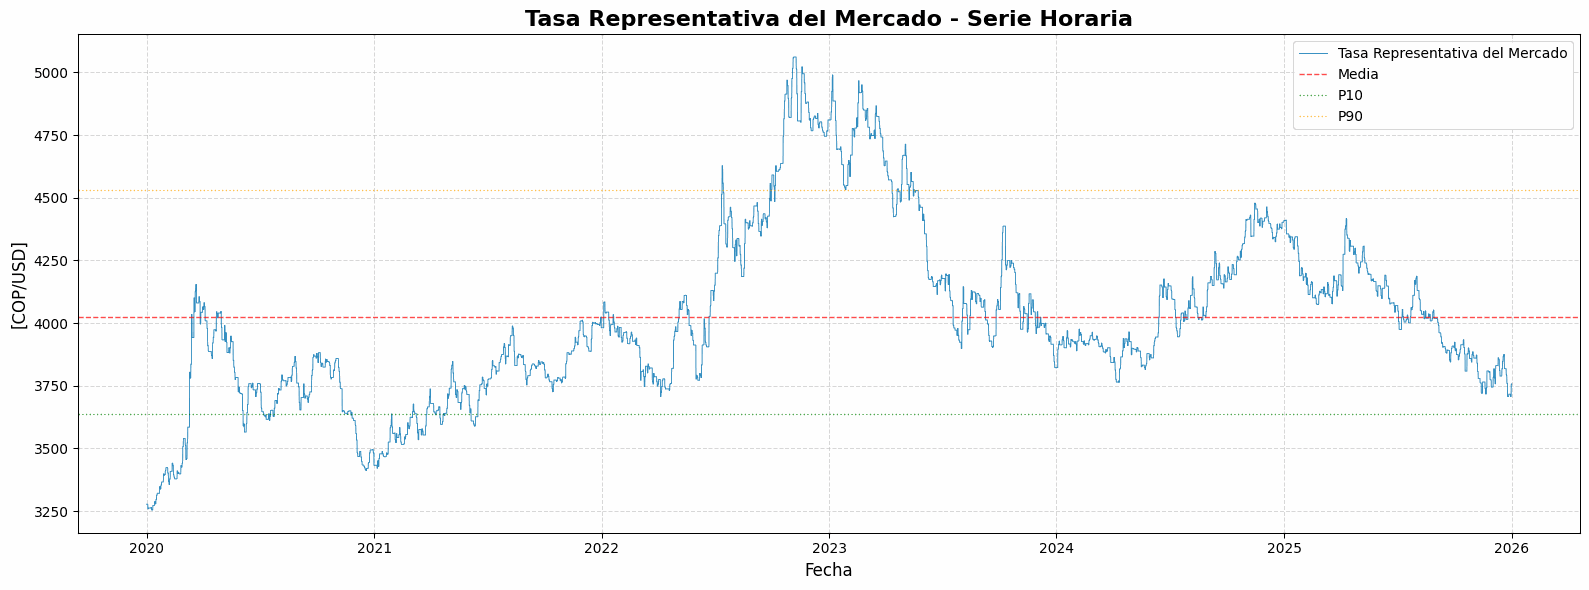

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_trm['trm'], color='#0072B2', linewidth=0.7, alpha=0.8, label='Tasa Representativa del Mercado')
plt.title('Tasa Representativa del Mercado - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[COP/USD]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

# Resumen visual: media y percentiles
media = df_trm['trm'].mean()
p10 = df_trm['trm'].quantile(0.10)
p90 = df_trm['trm'].quantile(0.90)
plt.axhline(media, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Media')
plt.axhline(p10, color='green', linestyle=':', linewidth=1, alpha=0.7, label='P10')
plt.axhline(p90, color='orange', linestyle=':', linewidth=1, alpha=0.7, label='P90')
plt.legend()
plt.show()

### 5. Creación del segmento de para análisis del Dataset

In [ ]:
df_trm = df_trm.reset_index(drop=True)

In [ ]:
df_trm

,fecha,periodo,trm
0,2020-01-01,1,3277.14
1,2020-01-01,2,3277.14
2,2020-01-01,3,3277.14
3,2020-01-01,4,3277.14
4,2020-01-01,5,3277.14
...,...,...,...
52603,2025-12-31,20,3757.08
52604,2025-12-31,21,3757.08
52605,2025-12-31,22,3757.08
52606,2025-12-31,23,3757.08


# **Cargue manual de información**

### **Pronóstico y Demanda Real**

### Importación de la información a analizar

In [18]:
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
ruta = Path("/content/drive/MyDrive/ColabNotebooks/ProyectoEspecializacion/DemandaReal/InformesMensualesDemanda")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
archivos = list(ruta.glob("*.xlsx"))

lista_datos = []

for archivo in archivos:
    df_pronostico = pd.read_excel(archivo, sheet_name="pronostico")
    df_real = pd.read_excel(archivo, sheet_name="real")

    df_pronostico["tipo"] = "pronostico"
    df_real["tipo"] = "real"
    df_pronostico["archivo"] = archivo.name
    df_real["archivo"] = archivo.name

    lista_datos.append(df_pronostico)
    lista_datos.append(df_real)

df_procesado = pd.concat(lista_datos, ignore_index=True)
df_procesado.head(5)

,UCP,Varialble,FECHA,TIPO_DIA,P1,P2,P3,P4,P5,P6,...,P21,P22,P23,P24,Total,PO19,PO20,PO21,tipo,archivo
0,MC-Celsia,OFI,2021-04-01,JSS,256.665969,244.611195,237.231368,234.887560,234.893894,232.404390,...,306.899474,291.303650,268.860105,251.401904,6334.533610,337.889946,346.952331,342.778474,pronostico,MC-Celsia-202104.xlsx
1,MC-Celsia,OFI,2021-04-02,VSS,238.793597,227.026002,220.591533,216.425590,216.006601,216.102370,...,295.327135,283.852833,265.920119,250.393597,5985.480176,323.751520,335.756570,331.214892,pronostico,MC-Celsia-202104.xlsx
2,MC-Celsia,OFI,2021-04-03,SSS,251.514852,239.441926,236.690794,234.881191,237.338512,241.057881,...,327.037418,308.367118,284.094393,263.914977,6677.416836,364.321848,375.503399,363.625529,pronostico,MC-Celsia-202104.xlsx
3,MC-Celsia,OFI,2021-04-04,DSS,238.550950,228.366805,221.920458,218.321097,216.413075,217.785406,...,304.254332,291.048651,275.429351,255.963911,6018.919803,325.302236,344.350827,339.110787,pronostico,MC-Celsia-202104.xlsx
4,MC-Celsia,OFI,2021-04-05,LUNES,264.000000,255.000000,251.000000,250.000000,252.000000,256.000000,...,344.000000,327.000000,302.000000,279.000000,7040.000000,360.561705,371.426437,362.415872,pronostico,MC-Celsia-202104.xlsx


In [20]:
import os
from pathlib import Path

ruta = Path("/content/drive/MyDrive/ProyectoEspecializacion/DemandaReal/InformesMensualesDemanda")

if ruta.exists() and ruta.is_dir():
    print(f"Contents of {ruta}:")
    for item in ruta.iterdir():
        print(item.name)
else:
    print(f"The directory {ruta} does not exist or is not a directory.")


The directory /content/drive/MyDrive/ProyectoEspecializacion/DemandaReal/InformesMensualesDemanda does not exist or is not a directory.


In [21]:
# ==============================
# Pivotear horas a filas
# ==============================
id_cols = ["FECHA", "TIPO_DIA", "tipo"]

hora_cols = [
    c for c in df_procesado.columns
    if c.upper().startswith("P")
    and c[1:].isdigit()
    and 1 <= int(c[1:]) <= 24
]

print("Columnas horarias finales:", hora_cols)

df_largo = df_procesado.melt(
    id_vars=id_cols,
    value_vars=hora_cols,
    var_name="Periodo",
    value_name="Energia"
)

df_largo["Periodo"] = df_largo["Periodo"].str.replace("P", "", regex=False).astype(int)

Columnas horarias finales: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'P14', 'P15', 'P16', 'P17', 'P18', 'P19', 'P20', 'P21', 'P22', 'P23', 'P24']


In [22]:
# ==============================
# Se separar la Deamnda Real y el Pronóstico OR en Columnas
# ==============================
df_pivot = df_largo.pivot_table(
    index=["FECHA", "Periodo", "TIPO_DIA"],
    columns="tipo",
    values="Energia"
).reset_index()

df_pivot = df_pivot.rename(columns={
    "real": "demanda_real",
    "pronostico": "pronostico"
})

#Se renombran los campos FECHA=Fecha y TIPO_DIA=TipoDia
df_pivot = df_pivot.sort_values(["FECHA", "Periodo"])
df_pivot = df_pivot.rename(columns={"Periodo": "periodo"})
df_pivot = df_pivot.rename(columns={"FECHA": "fecha"})
df_pivot = df_pivot.rename(columns={"TIPO_DIA": "tipo_dia"})
df_demanda = df_pivot.copy()

In [23]:
df_demanda

tipo,fecha,periodo,tipo_dia,pronostico,demanda_real
0,2020-01-01,1,1--ENE,256.800249,239.95562
1,2020-01-01,2,1--ENE,245.122164,230.08609
2,2020-01-01,3,1--ENE,232.794363,220.81891
3,2020-01-01,4,1--ENE,222.600543,214.77489
4,2020-01-01,5,1--ENE,215.022390,209.83059
...,...,...,...,...,...
52603,2025-12-31,20,31--DIC,326.490630,342.40726
52604,2025-12-31,21,31--DIC,320.175058,331.80096
52605,2025-12-31,22,31--DIC,304.393106,317.10690
52606,2025-12-31,23,31--DIC,286.137426,308.10374


In [24]:
df_diario = (df_pivot.groupby("fecha", as_index=False).agg({"demanda_real": "sum","pronostico": "sum","tipo_dia": "first"}))   # conservar clasificación del día
df_diario

tipo,fecha,demanda_real,pronostico,tipo_dia
0,2020-01-01,5462.38680,5600.921586,1--ENE
1,2020-01-02,6912.10553,6418.935810,2--ENE
2,2020-01-03,7427.61351,6871.271493,VIVENE
3,2020-01-04,7058.44777,6514.915305,SAVENE
4,2020-01-05,6420.73385,5755.419429,DOVENE
...,...,...,...,...
2187,2025-12-27,6796.16382,6712.945400,SAVDIC
2188,2025-12-28,6141.22019,5990.792973,DOVDIC
2189,2025-12-29,6890.84959,6838.502290,LUVDIC
2190,2025-12-30,6973.92855,7095.481437,MAVDIC


In [16]:
# # ruta del archivo y carga del dataset
# from google.colab import drive # dar a acceso
# drive.mount('/content/drive') # conectar al drive
# from pathlib import Path
# root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# # Exportación dataset
# root.mkdir(parents=True, exist_ok=True)

# ruta_salida = root / 'df_dataset_demanda_valle_2020al2026.xlsx'
# df_diario.to_excel(ruta_salida, index=False)

In [ ]:
df_pivot.groupby("fecha")[["demanda_real", "pronostico"]].sum().reset_index()

tipo,fecha,demanda_real,pronostico
0,2020-01-01,5462.38680,5600.921586
1,2020-01-02,6912.10553,6418.935810
2,2020-01-03,7427.61351,6871.271493
3,2020-01-04,7058.44777,6514.915305
4,2020-01-05,6420.73385,5755.419429
...,...,...,...
2187,2025-12-27,6796.16382,6712.945400
2188,2025-12-28,6141.22019,5990.792973
2189,2025-12-29,6890.84959,6838.502290
2190,2025-12-30,6973.92855,7095.481437


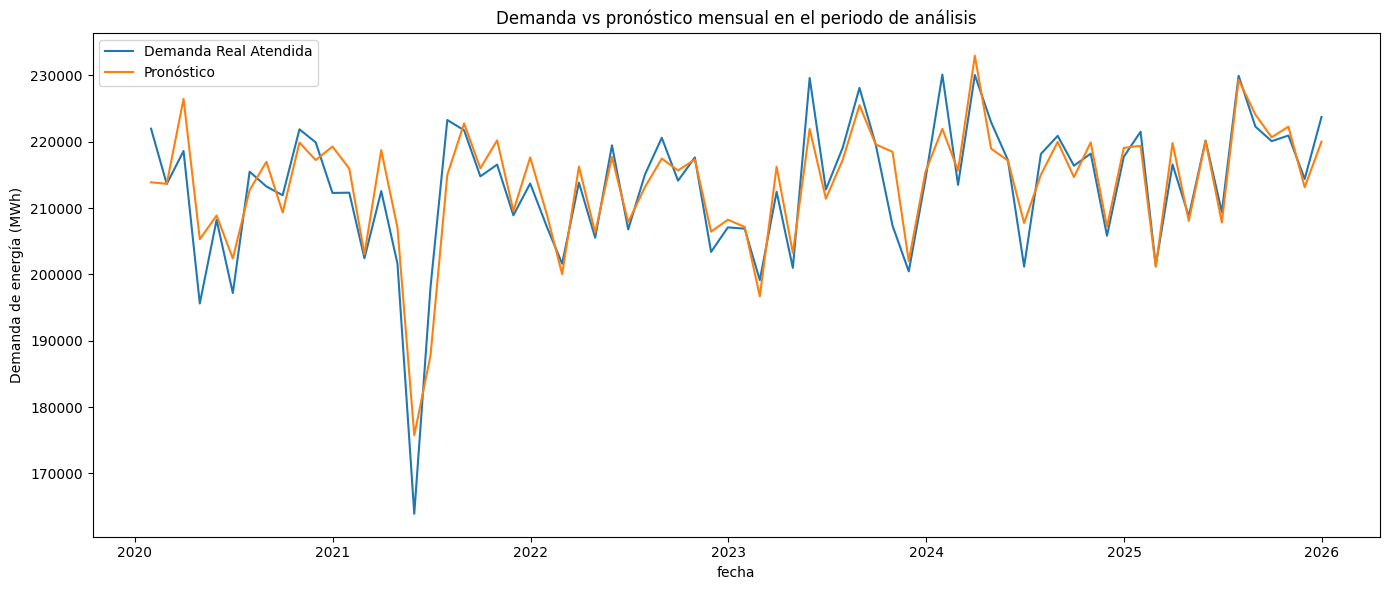

In [ ]:
df_mensual = (
    df_pivot
        .groupby(pd.Grouper(key="fecha", freq="ME"))[["demanda_real", "pronostico"]]
        .sum()
        .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(df_mensual["fecha"], df_mensual["demanda_real"], label="Demanda Real Atendida")
plt.plot(df_mensual["fecha"], df_mensual["pronostico"], label="Pronóstico")

plt.title("Demanda vs pronóstico mensual en el periodo de análisis")
plt.xlabel("fecha")
plt.ylabel("Demanda de energía (MWh)")
plt.legend()
plt.tight_layout()

plt.show()

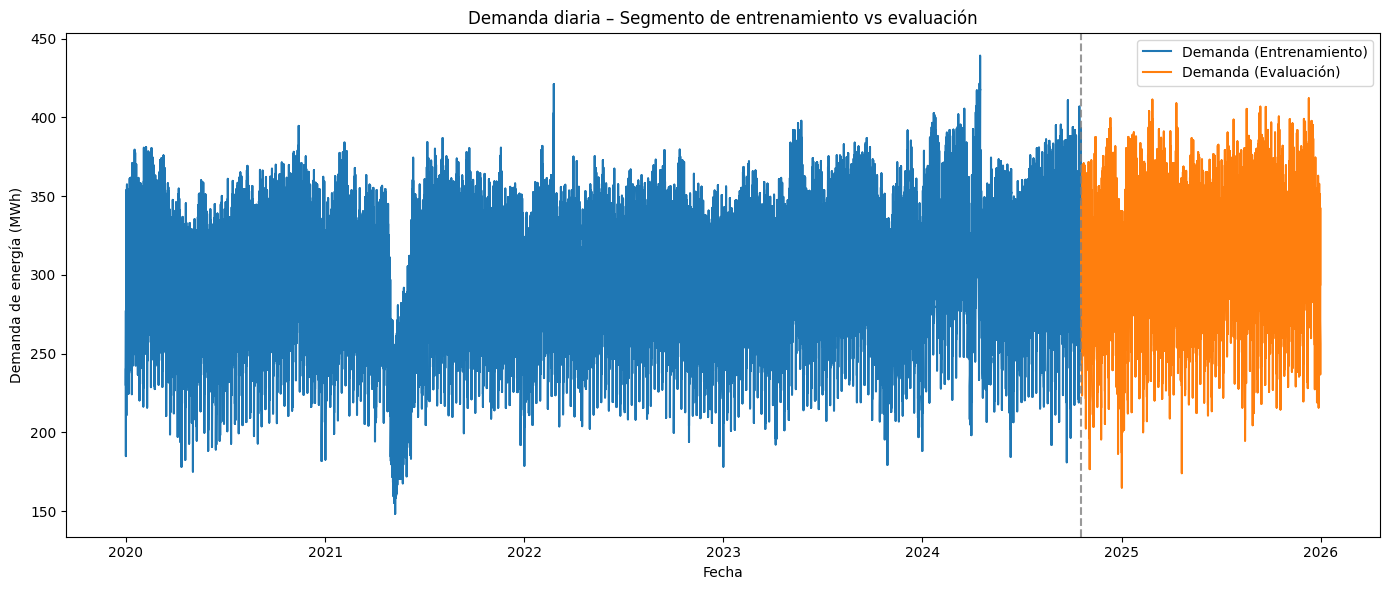

In [ ]:
df = df_pivot.copy()
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha")

# Fechas de corte
fecha_corte = pd.to_datetime("2024-10-18")

# Segmentos
df_train = df[df["fecha"] <= fecha_corte]
df_test  = df[df["fecha"] > fecha_corte]

plt.figure(figsize=(14, 6))

# Demanda real
plt.plot(df_train["fecha"], df_train["demanda_real"],
         label="Demanda (Entrenamiento)", color="tab:blue")

plt.plot(df_test["fecha"], df_test["demanda_real"],
         label="Demanda (Evaluación)", color="tab:orange")

# Opcionalmente se gráfica el Pronóstico presentado por el OR
# plt.plot(df_train["Fecha"], df_train["PronDem"],
#          label="Pronóstico (Entrenamiento)", color="tab:green", alpha=0.7)

# plt.plot(df_test["Fecha"], df_test["PronDem"],
#          label="Pronóstico (Evaluación)", color="tab:red", alpha=0.7)

# Línea vertical de separación
plt.axvline(fecha_corte, linestyle="--", color="gray", alpha=0.8)

plt.title("Demanda diaria – Segmento de entrenamiento vs evaluación")
plt.xlabel("Fecha")
plt.ylabel("Demanda de energía (MWh)")
plt.legend()
plt.tight_layout()
plt.show()

### **IPC e IPP**

### Importación de la información a analizar

In [ ]:
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_IPP_IPC = pd.read_csv(root / 'Dataset_IPP-IPC.csv',sep=';')


In [ ]:
df_IPP_IPC

,Fecha,IPP,IPC,IPC_Cali
0,31/01/2020,122.34,104.24,105.14
1,29/02/2020,122.34,104.94,105.72
2,31/03/2020,123.27,105.53,106.33
3,30/04/2020,122.59,105.70,106.39
4,31/05/2020,122.50,105.36,106.11
...,...,...,...,...
67,31/08/2025,184.62,150.99,151.46
68,30/09/2025,185.51,151.48,151.59
69,31/10/2025,184.22,151.76,152.15
70,30/11/2025,182.03,151.87,152.10


### 3. Manipulación de datos

In [ ]:
df_IPP_IPC["Fecha"] = pd.to_datetime(df_IPP_IPC["Fecha"], format="%d/%m/%Y")

In [ ]:
df_IPP_IPC["inicio_mes"] = df_IPP_IPC["Fecha"].dt.to_period("M").dt.to_timestamp()
df_IPP_IPC["fin_mes"] = df_IPP_IPC["inicio_mes"] + pd.offsets.MonthEnd(0)

In [ ]:
registros = []

for _, row in df_IPP_IPC.iterrows():
    fechas = pd.date_range(
        start=row["inicio_mes"],
        end=row["fin_mes"],
        freq="D"
    )

    for f in fechas:
        registros.append({
            "fecha": f,
            "IPP": row["IPP"],
            "IPC": row["IPC"],
            "IPC_Cali": row["IPC_Cali"]
        })

df_diario = pd.DataFrame(registros)

In [ ]:
df_diario = df_diario[
    (df_diario["fecha"] >= "2020-01-01") &
    (df_diario["fecha"] <= "2025-12-31")
]

In [ ]:
periodos = pd.DataFrame({"periodo": range(1, 25)})

df_final = (
    df_diario
    .merge(periodos, how="cross")
    .sort_values(["fecha", "periodo"])
    .reset_index(drop=True)
)

In [ ]:
df_final["fecha"] = df_final["fecha"].dt.strftime("%Y-%m-%d")

df_final_IPP_IPC = df_final[["fecha", "periodo", "IPP", "IPC", "IPC_Cali"]]

df_final_IPP_IPC = df_final_IPP_IPC.rename(columns={"IPP": "ipp","IPC": "ipc","IPC_Cali": "ipc_cali"  # recomendado mantener consistencia
    }
)

In [ ]:
df_final_IPP_IPC["FechaHora"] = (
    pd.to_datetime(df_trm["fecha"])
    + pd.to_timedelta(df_trm["periodo"].astype(int) - 1, unit="H")
)

Validación de registros duplicados

In [ ]:
duplicados = df_final_IPP_IPC.duplicated(subset=['FechaHora', 'ipp', 'ipc','ipc_cali'], keep=False)
if duplicados.any():
    print("Existen duplicados por FechaHora, ipp, ipc y ipc_cali.")
    print(df_final_IPP_IPC[duplicados])
else:
    print("No existen duplicados por FechaHora, ipp, ipc y ipc_cali.")

No existen duplicados por FechaHora, ipp, ipc y ipc_cali.


Validación de completitud de la información

In [ ]:
df_final_IPP_IPC = df_final_IPP_IPC.set_index("FechaHora").sort_index()
#Construir el rango horario esperado
fecha_min = df_final_IPP_IPC.index.min()
fecha_max = df_final_IPP_IPC.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"
)

# Horas faltantes
faltantes = rango_horas.difference(df_final_IPP_IPC.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(df_trm)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio y estadístico

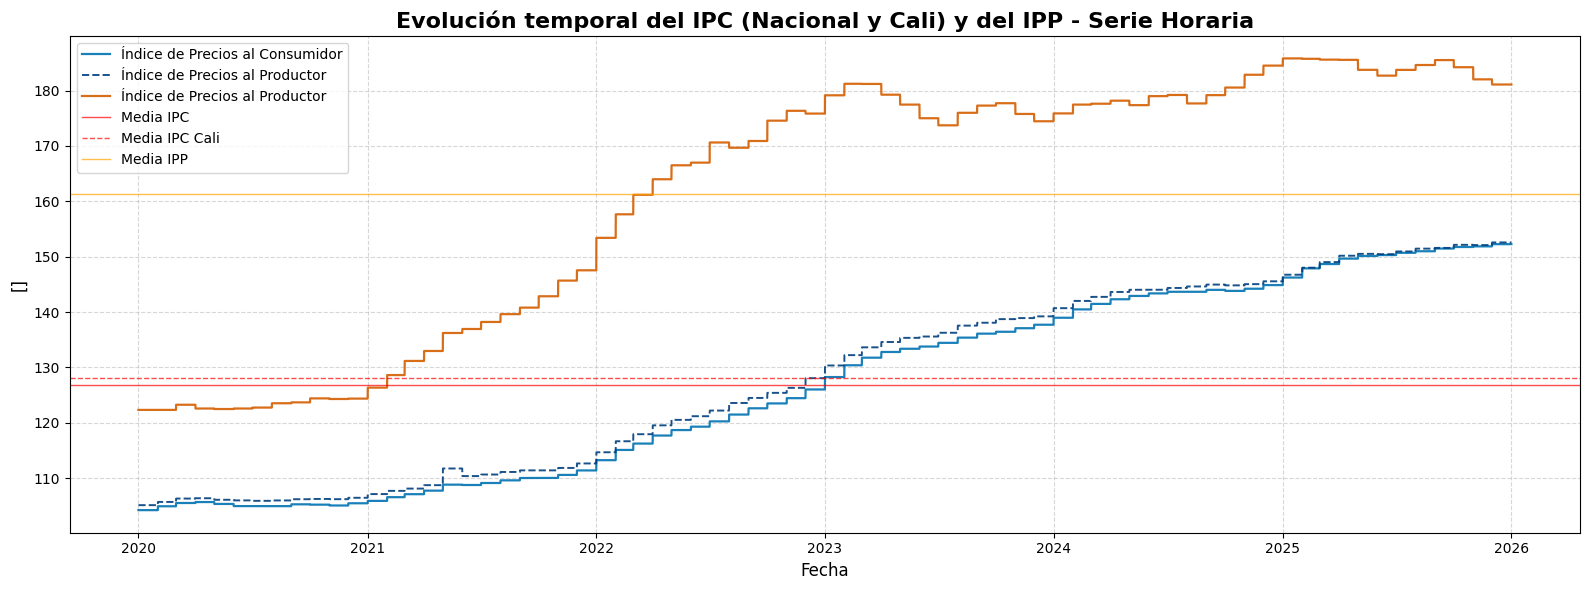

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_final_IPP_IPC['ipc'], color='#0072B2', linewidth=1.6, linestyle='-', alpha=0.9, label='Índice de Precios al Consumidor')
plt.plot(df_final_IPP_IPC['ipc_cali'], color='#003f7f', linewidth=1.4, linestyle='--', alpha=0.9, label='Índice de Precios al Productor')
plt.plot(df_final_IPP_IPC['ipp'], color='#D55E00', linewidth=1.6, linestyle='-', alpha=0.9, label='Índice de Precios al Productor')
plt.title('Evolución temporal del IPC (Nacional y Cali) y del IPP - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

# Resumen visual: media y percentiles
media_ipc = df_final_IPP_IPC['ipc'].mean()
media_ipc_cali = df_final_IPP_IPC['ipc_cali'].mean()
media_ipp = df_final_IPP_IPC['ipp'].mean()
plt.axhline(media_ipc, color='red', linestyle='-', linewidth=1, alpha=0.7, label='Media IPC')
plt.axhline(media_ipc_cali, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Media IPC Cali')
plt.axhline(media_ipp, color='orange', linestyle='-', linewidth=1, alpha=0.7, label='Media IPP')
plt.legend()
plt.show()

### 5. Creación del segmento de para análisis del Dataset

In [ ]:
df_final_IPP_IPC = df_final_IPP_IPC.reset_index(drop=True)
df_final_IPP_IPC['fecha'] = pd.to_datetime(df_final_IPP_IPC['fecha'])
df_final_IPP_IPC

,fecha,periodo,ipp,ipc,ipc_cali
0,2020-01-01,1,122.34,104.24,105.14
1,2020-01-01,2,122.34,104.24,105.14
2,2020-01-01,3,122.34,104.24,105.14
3,2020-01-01,4,122.34,104.24,105.14
4,2020-01-01,5,122.34,104.24,105.14
...,...,...,...,...,...
52603,2025-12-31,20,181.10,152.27,152.58
52604,2025-12-31,21,181.10,152.27,152.58
52605,2025-12-31,22,181.10,152.27,152.58
52606,2025-12-31,23,181.10,152.27,152.58


# **Capacidad solar  y termica**

Para cuantificar la capacidad de autogeneración solar y térmica, se realizó la busqueda de los proyectos de Autogeneración a Gran Escala (AGGE), Autogenración a Pequeña Escala (AGPE) y Cogeneración que han ingresado durante el periodo de análisis. Los proyectos de Generación y Autogeneración puros fueron excluidos debido a que estos no tiene influencia en la ecuación de demanda de energía del mercado ya que por definición son restados en la ecuación.   

### Importación de la información a analizar

In [ ]:
# 2 ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(root / 'Dataset_CapacidadSolarTermica.csv',sep=';')

In [ ]:
df

,fecha_operacion,capacidad,solar,termica
0,15/08/2004,3000.0,0,1
1,18/05/2009,19900.0,0,1
2,26/01/2010,10000.0,0,1
3,17/08/2010,30000.0,0,1
4,23/07/2011,3000.0,0,1
...,...,...,...,...
906,24/12/2025,3300.0,1,0
907,24/12/2025,3300.0,1,0
908,24/12/2025,3300.0,1,0
909,30/12/2025,3.0,1,0


### 3. Manipulación de datos

In [ ]:
df.columns = df.columns.str.lower().str.strip()
df["fecha_operacion"] = pd.to_datetime(df["fecha_operacion"])
df["capacidad"] = pd.to_numeric(df["capacidad"], errors="coerce")
df["solar"] = df["solar"].astype(int)
df["termica"] = df["termica"].astype(int)

In [ ]:
# ===============================
# 2. Separar capacidad por tipo
# ===============================
df["capacidad_solar"] = df["capacidad"] * df["solar"]
df["capacidad_termica"] = df["capacidad"] * df["termica"]

# ===============================
# 3. Agregar por fecha de operación
# ===============================
df_daily = (
    df.groupby("fecha_operacion", as_index=False)
      .agg(
          capacidad_solar=("capacidad_solar", "sum"),
          capacidad_termica=("capacidad_termica", "sum")
      )
      .sort_values("fecha_operacion")
)

# ===============================
# 4. Capacidad acumulada instalada
# ===============================
df_daily["capacidad_solar"] = df_daily["capacidad_solar"].cumsum()
df_daily["capacidad_termica"] = df_daily["capacidad_termica"].cumsum()

# ===============================
# 5. Crear eje horario completo
# ===============================
fechas_horas = pd.date_range(
    start="2020-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

df_base = pd.DataFrame({"fecha_hora": fechas_horas})
df_base["fecha"] = df_base["fecha_hora"].dt.floor("D")
df_base["periodo"] = df_base["fecha_hora"].dt.hour + 1

# ===============================
# 6. Unir y propagar capacidad vigente
# ===============================
df_final = df_base.merge(
    df_daily,
    left_on="fecha",
    right_on="fecha_operacion",
    how="left"
)

df_final[["capacidad_solar", "capacidad_termica"]] = (
    df_final[["capacidad_solar", "capacidad_termica"]].ffill()
)

# ===============================
# 7. Flags
# ===============================
df_final["solar"] = (df_final["capacidad_solar"] > 0).astype(int)
df_final["termica"] = (df_final["capacidad_termica"] > 0).astype(int)

# ===============================
# 8. Selección final
# ===============================
df_final = df_final[[
    "fecha",
    "periodo",
    "capacidad_solar",
    "capacidad_termica",
    "solar",
    "termica"
]]

df_final = df_final.sort_values(["fecha", "periodo"]).reset_index(drop=True)


In [ ]:
df_final["FechaHora"] = (
    pd.to_datetime(df_trm["fecha"])
    + pd.to_timedelta(df_trm["periodo"].astype(int) - 1, unit="H")
)

Validación de registros duplicados

In [ ]:
duplicados = df_final.duplicated(subset=['FechaHora'], keep=False)
if duplicados.any():
    print("Existen duplicados por FechaHora.")
    print(df_final[duplicados])
else:
    print("No existen duplicados por FechaHora.")

No existen duplicados por FechaHora.


Validación de completitud de la información

In [ ]:
df_final = df_final.set_index("FechaHora").sort_index()
#Construir el rango horario esperado
fecha_min = df_final.index.min()
fecha_max = df_final.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"
)

# Horas faltantes
faltantes = rango_horas.difference(df_final.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(df_trm)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio y estadístico

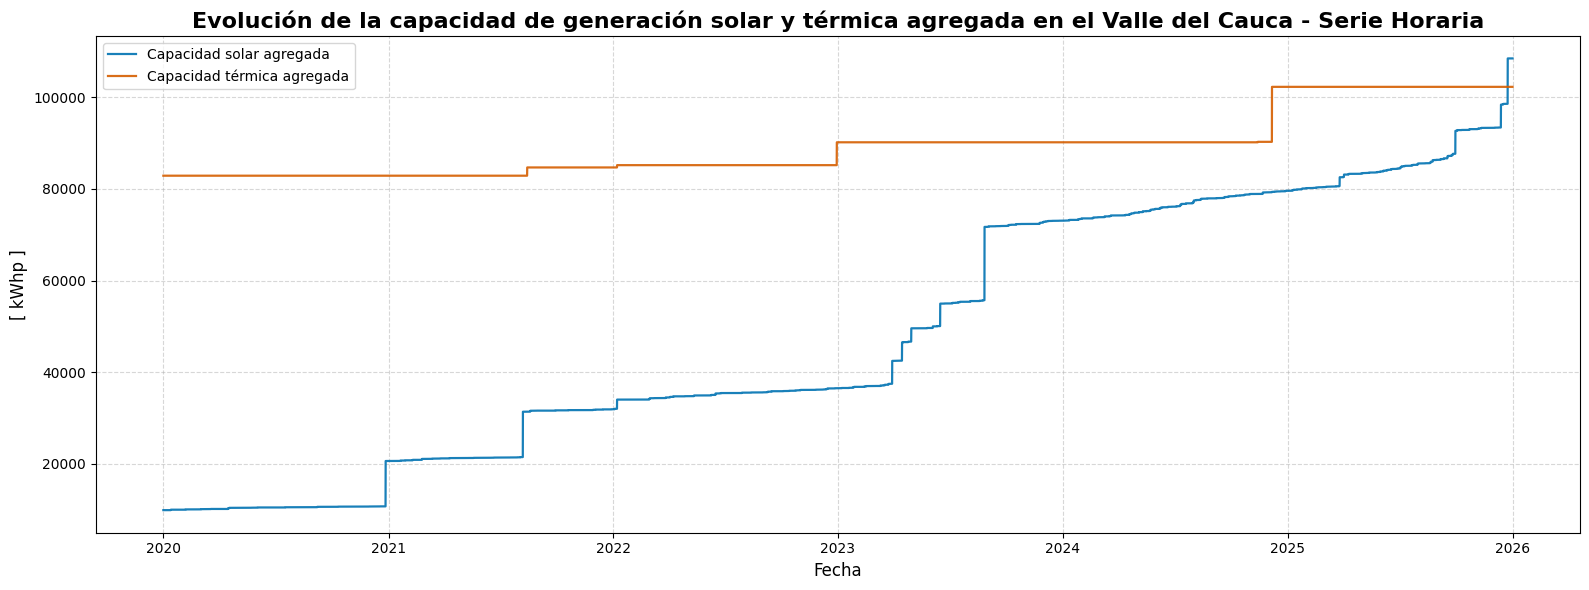

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_final['capacidad_solar'], color='#0072B2', linewidth=1.6, linestyle='-', alpha=0.9, label='Capacidad solar agregada')
plt.plot(df_final['capacidad_termica'], color='#D55E00', linewidth=1.6, linestyle='-', alpha=0.9, label='Capacidad térmica agregada')
plt.title('Evolución de la capacidad de generación solar y térmica agregada en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[ kWhp ]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

plt.legend()
plt.show()

### 5. Creación del segmento de para análisis del Dataset

In [ ]:
df_final = df_final.drop(columns=["solar","termica"])
df_cap_solar_termica = df_final.reset_index(drop=True)
df_cap_solar_termica

,fecha,periodo,capacidad_solar,capacidad_termica
0,2020-01-01,1,9913.64,82900.0
1,2020-01-01,2,9913.64,82900.0
2,2020-01-01,3,9913.64,82900.0
3,2020-01-01,4,9913.64,82900.0
4,2020-01-01,5,9913.64,82900.0
...,...,...,...,...
52603,2025-12-31,20,108494.17,102290.0
52604,2025-12-31,21,108494.17,102290.0
52605,2025-12-31,22,108494.17,102290.0
52606,2025-12-31,23,108494.17,102290.0


****

# **Cantidad de suscriptores del servicio de energía SUI-SSPD**

Para el periodo de análisis se encontró que en la plataforma de la SUI existían 14 distintas clasificaciones para ESTRATO y 3 distintas clasificaciones para el TIPO DE USUARIO, por lo cual inicialmente se intento agrupar los suscriptores (ESTRATO) en 5 distintos grupos de usuarios (cliente_residencial, cliente_industrial, cliente_comercial, cliente_oficial y cliente_ap), donde cada clasificación agrupa a los usuarios sin importar el mercado al que pertenece el TIPO DE USUARIO (SIN DATO, Regulado, No regulado). El detalle de las 5 clasificaciones realizadas son:

* cliente_residencial: Agrupa a todos los suscriptores del tipo residencial puro: Residencial Bajo-Bajo, Residencial Bajo, Residencial Medio-Bajo, Residencial Medio, Residencial Medio-Alto y Residencial Alto.

* cliente_industrial: Agrupa a los suscriptores del tipo Industrial, Industrial Bombeo y Distrito Riego.

* cliente_comercial: Agrupa a los suscriptores del tipo Comercial, Provisional y Areas Comunes.

* cliente_oficial: Agrupa exclusivamente a los suscriptores del tipo Oficial.

* cliente_ap: Agrupa exclusivamente a los suscriptores del tipo Alumbrado Público (AP).  

### Importación de la información a analizar

In [ ]:
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(root /'DatasetSUI_desde 2020-2025.csv',sep=';')

In [ ]:
# --------------------------------------------------
# 2. FUNCION PARA NORMALIZAR TEXTO
# --------------------------------------------------
def normalizar_texto(texto):
    texto = str(texto).lower().strip()
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ascii', 'ignore').decode('utf-8')
    texto = texto.replace(' ', '_')
    return texto

In [ ]:
# --------------------------------------------------
# 3. NORMALIZAR NOMBRES DE COLUMNAS
# --------------------------------------------------
df.columns = [normalizar_texto(c) for c in df.columns]
df = df.rename(columns={"numero_de_suscriptores_*": "suscriptores"})
# --------------------------------------------------
# 4. LIMPIAR Y RELLENAR CAMPO MES
# --------------------------------------------------
df['mes'] = pd.to_datetime(df['mes'], dayfirst=True, errors='coerce')
df['mes'] = df['mes'].ffill()

In [ ]:
# --------------------------------------------------
# 5. NORMALIZAR Y CLASIFICAR ESTRATO
# --------------------------------------------------
df['estrato'] = df['estrato'].apply(normalizar_texto)

def clasificar_cliente(estrato):
    if 'residencial_bajo-bajo' in estrato or 'residencial_bajo' in estrato or 'residencial_medio-bajo' in estrato or 'residencial_medio' in estrato or 'residencial_medio-alto' in estrato or 'residencial_alto' in estrato:
        return 'cliente_residencial'
    elif 'industrial' in estrato or 'distrito_riego' in estrato or 'industrial_bombeo' in estrato:
        return 'cliente_industrial'
    elif 'comercial' in estrato or 'provisional' in estrato or 'areas_comunes' in estrato:
        return 'cliente_comercial'
    elif 'oficial' in estrato:
        return 'cliente_oficial'
    elif 'alumbrado' in estrato or 'publico' in estrato:
        return 'cliente_ap'
    else:
        return 'otros'

df['tipo_cliente'] = df['estrato'].apply(clasificar_cliente)

In [ ]:
def clasificacion_residencial(estrato):
    if 'residencial_bajo-bajo' in estrato or 'residencial_bajo' in estrato or 'residencial_medio-bajo' in estrato or 'residencial_medio' in estrato or 'residencial_medio-alto' in estrato or 'residencial_alto' in estrato:
        return 'residencial'
    else:
        return 'no_residencial'

In [ ]:
df['tipo_cliente2'] = df['estrato'].apply(clasificacion_residencial)

In [ ]:
# --------------------------------------------------
# 6. LIMPIAR CAMPO SUSCRIPTORES
# --------------------------------------------------
df['suscriptores'] = (
    df['suscriptores']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
    .astype(int)
)

In [ ]:
# --------------------------------------------------
# 7. AGRUPAR INFORMACION MENSUAL
# --------------------------------------------------
df_agrupado = (
    df.groupby(['mes', 'tipo_cliente2'], as_index=False)
      .agg({'suscriptores': 'sum'})
)

df_pivot = (
    df_agrupado
    .pivot(index='mes', columns='tipo_cliente2', values='suscriptores')
    .fillna(0)
    .reset_index()
)

In [ ]:
# --------------------------------------------------
# 8. CREAR CALENDARIO DIARIO + PERIODOS HORARIOS
# --------------------------------------------------
fechas = pd.date_range(
    start='2020-01-01',
    end='2025-12-31',
    freq='D'
)

periodos = range(1, 25)

df_tiempo = pd.MultiIndex.from_product(
    [fechas, periodos],
    names=['fecha', 'periodo']
).to_frame(index=False)

# --------------------------------------------------
# 9. UNIR INFORMACION MENSUAL CON CALENDARIO
# --------------------------------------------------
df_pivot['mes_periodo'] = df_pivot['mes'].dt.to_period('M')
df_tiempo['mes_periodo'] = df_tiempo['fecha'].dt.to_period('M')

df_suscriptores = (
    df_tiempo
    .merge(
        df_pivot.drop(columns='mes'),
        on='mes_periodo',
        how='left'
    )
    .drop(columns='mes_periodo')
    .fillna(0)
)

In [ ]:
df_suscriptores["FechaHora"] = (
    pd.to_datetime(df_trm["fecha"])
    + pd.to_timedelta(df_trm["periodo"].astype(int) - 1, unit="H")
)

Validación de registros duplicados

In [ ]:
duplicados = df_suscriptores.duplicated(subset=['FechaHora'], keep=False)
if duplicados.any():
    print("Existen duplicados por FechaHora.")
    print(df_suscriptores[duplicados])
else:
    print("No existen duplicados por FechaHora.")

No existen duplicados por FechaHora.


Validación de completitud de la información

In [ ]:
df_suscriptores = df_suscriptores.set_index("FechaHora").sort_index()
#Construir el rango horario esperado
fecha_min = df_suscriptores.index.min()
fecha_max = df_suscriptores.index.max()

rango_horas = pd.date_range(
    start=fecha_min,
    end=fecha_max,
    freq="h"
)

# Horas faltantes
faltantes = rango_horas.difference(df_suscriptores.index)

if len(faltantes) > 0:
    print(f"❌ Faltan {len(faltantes)} horas en el periodo")
    print("Ejemplo de horas faltantes:")
    print(faltantes[:10])
else:
    print("✅ Existe un valor para cada hora en el periodo")

print("\n📊 RESUMEN")
print(f"Fecha mínima      : {fecha_min}")
print(f"Fecha máxima      : {fecha_max}")
print(f"Horas esperadas   : {len(rango_horas)}")
print(f"Horas registradas : {len(df_trm)}")
print(f"Horas faltantes   : {len(faltantes)}")

✅ Existe un valor para cada hora en el periodo

📊 RESUMEN
Fecha mínima      : 2020-01-01 00:00:00
Fecha máxima      : 2025-12-31 23:00:00
Horas esperadas   : 52608
Horas registradas : 52608
Horas faltantes   : 0


### 4. Análisis exploratorio

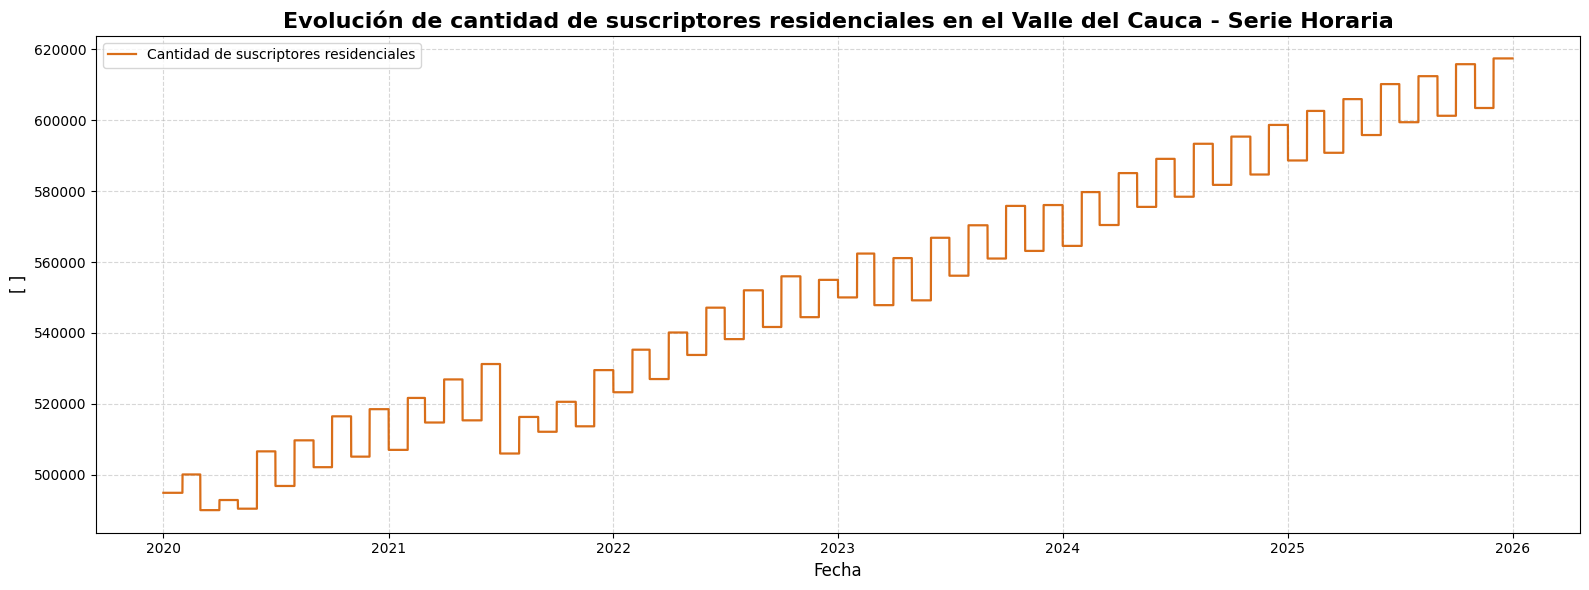

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_suscriptores['residencial'], color='#D55E00', linewidth=1.6, linestyle='-', alpha=0.9, label='Cantidad de suscriptores residenciales')
plt.title('Evolución de cantidad de suscriptores residenciales en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[ ]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

plt.legend()
plt.show()

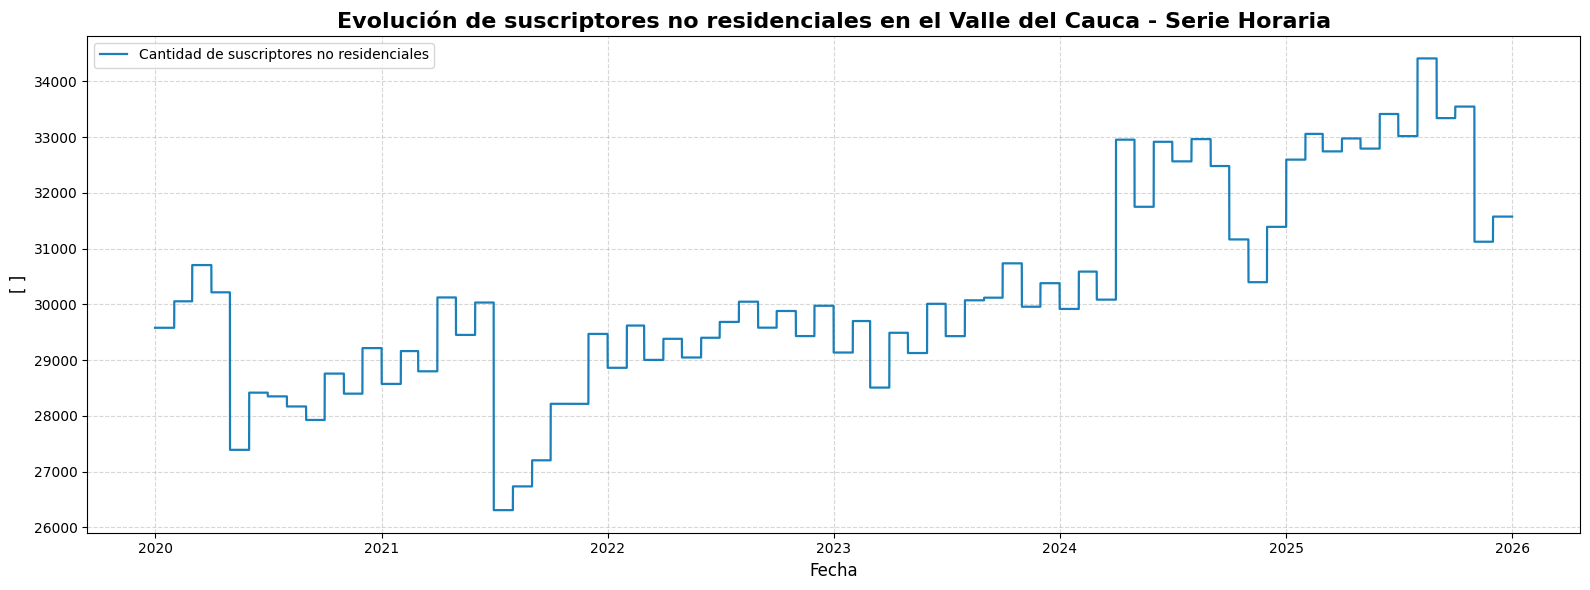

In [ ]:
plt.figure(figsize=(16,6))
plt.plot(df_suscriptores['no_residencial'], color='#0072B2', linewidth=1.6, linestyle='-', alpha=0.9, label='Cantidad de suscriptores no residenciales')
plt.title('Evolución de suscriptores no residenciales en el Valle del Cauca - Serie Horaria', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('[ ]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()

plt.legend()
plt.show()

### 5. Creación del segmento de para análisis del Dataset

In [ ]:
df_suscriptores = df_suscriptores.reset_index(drop=True)
df_suscriptores

,fecha,periodo,no_residencial,residencial
0,2020-01-01,1,29579,494874
1,2020-01-01,2,29579,494874
2,2020-01-01,3,29579,494874
3,2020-01-01,4,29579,494874
4,2020-01-01,5,29579,494874
...,...,...,...,...
52603,2025-12-31,20,31574,617447
52604,2025-12-31,21,31574,617447
52605,2025-12-31,22,31574,617447
52606,2025-12-31,23,31574,617447


# **Construcción del Dataset final**

In [ ]:
dfs = [
    df_demanda,
    df_trm,
    df_final_IPP_IPC,
    df_suscriptores,
    df_pbolsa,
    df_cap_solar_termica,
    df_climaticas
]

In [ ]:
for i, df in enumerate(dfs, 1):
    assert {'fecha', 'periodo'}.issubset(df.columns), f"Faltan llaves en df {i}"

In [ ]:
df_dataset = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=['fecha', 'periodo'],
        how='inner',
        validate='one_to_one'
    ),
    dfs
)

In [ ]:
df_dataset

,fecha,periodo,tipo_dia,pronostico,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,precio_bolsa,capacidad_solar,capacidad_termica,allsky_centro,allsky_centro_agroind,allsky_norte,allsky_norte_agroind,allsky_occidente,allsky_oriente,allsky_sur,clrsky_centro,clrsky_centro_agroind,clrsky_norte,clrsky_norte_agroind,clrsky_occidente,clrsky_oriente,clrsky_sur,prectotcorr_centro,prectotcorr_centro_agroind,prectotcorr_norte,prectotcorr_norte_agroind,prectotcorr_occidente,prectotcorr_oriente,prectotcorr_sur,rh2m_centro,rh2m_centro_agroind,rh2m_norte,rh2m_norte_agroind,rh2m_occidente,rh2m_oriente,rh2m_sur,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur
0,2020-01-01,1,1--ENE,256.800249,239.95562,3277.14,122.34,104.24,105.14,29579,494874,72.0169,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.79,1.39,2.73,2.12,2.26,1.41,2.21,98.88,100.00,99.95,99.36,98.28,99.54,100.00,20.86,16.33,19.61,18.96,22.32,13.63,14.48
1,2020-01-01,2,1--ENE,245.122164,230.08609,3277.14,122.34,104.24,105.14,29579,494874,136.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.04,1.53,2.18,1.97,2.98,1.61,2.24,98.98,100.00,99.81,99.34,98.46,99.37,100.00,20.79,16.14,19.53,18.89,22.24,13.46,14.28
2,2020-01-01,3,1--ENE,232.794363,220.81891,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.05,1.73,1.99,2.11,3.98,1.96,2.06,99.16,100.00,99.68,99.25,98.60,99.34,100.00,20.69,15.95,19.42,18.77,22.12,13.27,14.10
3,2020-01-01,4,1--ENE,222.600543,214.77489,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.30,1.66,1.71,1.99,4.83,1.98,1.64,99.28,100.00,99.38,99.05,98.71,99.26,100.00,20.61,15.78,19.30,18.63,22.04,13.13,13.91
4,2020-01-01,5,1--ENE,215.022390,209.83059,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.77,1.16,1.20,1.40,5.95,1.40,1.05,99.24,100.00,99.06,98.69,98.68,99.01,100.00,20.57,15.63,19.17,18.49,22.02,13.02,13.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2025-12-31,20,31--DIC,326.490630,342.40726,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.64,1.80,6.08,4.53,3.07,0.43,0.41,96.19,93.32,98.35,90.67,95.95,94.19,96.91,22.30,18.70,21.89,22.22,23.79,15.52,15.78
52604,2025-12-31,21,31--DIC,320.175058,331.80096,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.45,1.47,5.91,4.04,2.73,0.38,0.32,96.13,94.33,98.53,91.79,96.46,95.58,97.32,22.25,18.35,21.70,21.87,23.66,15.14,15.52
52605,2025-12-31,22,31--DIC,304.393106,317.10690,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.29,1.09,5.09,3.17,2.33,0.30,0.23,95.96,95.37,97.94,92.48,96.56,96.17,97.58,22.17,17.98,21.62,21.56,23.55,14.86,15.30
52606,2025-12-31,23,31--DIC,286.137426,308.10374,3757.08,181.10,152.27,152.58,31574,617447,272.7488,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.57,0.83,4.08,2.44,2.37,0.24,0.18,95.95,96.41,97.25,93.31,96.75,96.39,97.61,22.02,17.59,21.52,21.17,23.39,14.68,15.13


In [ ]:
df_dataset['ano'] = df_dataset['fecha'].dt.year
df_dataset['mes'] = df_dataset['fecha'].dt.month
df_dataset['dia'] = df_dataset['fecha'].dt.day

In [ ]:
df_dataset

,fecha,periodo,tipo_dia,pronostico,demanda_real,trm,ipp,ipc,ipc_cali,no_residencial,residencial,precio_bolsa,capacidad_solar,capacidad_termica,allsky_centro,allsky_centro_agroind,allsky_norte,allsky_norte_agroind,allsky_occidente,allsky_oriente,allsky_sur,clrsky_centro,clrsky_centro_agroind,clrsky_norte,clrsky_norte_agroind,...,clrsky_sur,prectotcorr_centro,prectotcorr_centro_agroind,prectotcorr_norte,prectotcorr_norte_agroind,prectotcorr_occidente,prectotcorr_oriente,prectotcorr_sur,rh2m_centro,rh2m_centro_agroind,rh2m_norte,rh2m_norte_agroind,rh2m_occidente,rh2m_oriente,rh2m_sur,t2m_centro,t2m_centro_agroind,t2m_norte,t2m_norte_agroind,t2m_occidente,t2m_oriente,t2m_sur,ano,mes,dia
0,2020-01-01,1,1--ENE,256.800249,239.95562,3277.14,122.34,104.24,105.14,29579,494874,72.0169,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.79,1.39,2.73,2.12,2.26,1.41,2.21,98.88,100.00,99.95,99.36,98.28,99.54,100.00,20.86,16.33,19.61,18.96,22.32,13.63,14.48,2020,1,1
1,2020-01-01,2,1--ENE,245.122164,230.08609,3277.14,122.34,104.24,105.14,29579,494874,136.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.04,1.53,2.18,1.97,2.98,1.61,2.24,98.98,100.00,99.81,99.34,98.46,99.37,100.00,20.79,16.14,19.53,18.89,22.24,13.46,14.28,2020,1,1
2,2020-01-01,3,1--ENE,232.794363,220.81891,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.05,1.73,1.99,2.11,3.98,1.96,2.06,99.16,100.00,99.68,99.25,98.60,99.34,100.00,20.69,15.95,19.42,18.77,22.12,13.27,14.10,2020,1,1
3,2020-01-01,4,1--ENE,222.600543,214.77489,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.30,1.66,1.71,1.99,4.83,1.98,1.64,99.28,100.00,99.38,99.05,98.71,99.26,100.00,20.61,15.78,19.30,18.63,22.04,13.13,13.91,2020,1,1
4,2020-01-01,5,1--ENE,215.022390,209.83059,3277.14,122.34,104.24,105.14,29579,494874,127.7139,9913.64,82900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.77,1.16,1.20,1.40,5.95,1.40,1.05,99.24,100.00,99.06,98.69,98.68,99.01,100.00,20.57,15.63,19.17,18.49,22.02,13.02,13.77,2020,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52603,2025-12-31,20,31--DIC,326.490630,342.40726,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.64,1.80,6.08,4.53,3.07,0.43,0.41,96.19,93.32,98.35,90.67,95.95,94.19,96.91,22.30,18.70,21.89,22.22,23.79,15.52,15.78,2025,12,31
52604,2025-12-31,21,31--DIC,320.175058,331.80096,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.45,1.47,5.91,4.04,2.73,0.38,0.32,96.13,94.33,98.53,91.79,96.46,95.58,97.32,22.25,18.35,21.70,21.87,23.66,15.14,15.52,2025,12,31
52605,2025-12-31,22,31--DIC,304.393106,317.10690,3757.08,181.10,152.27,152.58,31574,617447,284.4598,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.29,1.09,5.09,3.17,2.33,0.30,0.23,95.96,95.37,97.94,92.48,96.56,96.17,97.58,22.17,17.98,21.62,21.56,23.55,14.86,15.30,2025,12,31
52606,2025-12-31,23,31--DIC,286.137426,308.10374,3757.08,181.10,152.27,152.58,31574,617447,272.7488,108494.17,102290.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.57,0.83,4.08,2.44,2.37,0.24,0.18,95.95,96.41,97.25,93.31,96.75,96.39,97.61,22.02,17.59,21.52,21.17,23.39,14.68,15.13,2025,12,31


In [ ]:
# ruta del archivo y carga del dataset
from google.colab import drive # dar a acceso
drive.mount('/content/drive') # conectar al drive
from pathlib import Path
root = Path('/content/drive/MyDrive/ProyectoEspecializacion/data/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Exportación dataset
root.mkdir(parents=True, exist_ok=True)

ruta_salida = root / 'df_dataset_demanda_valle.xlsx'
df_dataset.to_excel(ruta_salida, index=False)